# Proyecto III – Clasificación automática de enfermedades foliares en hojas de caña de azúcar

Notebook unificado y organizado para proyecto de maestría.  
Incluye EDA, limpieza, normalización del dataset, entrenamiento, screening, fine-tuning, evaluación final, análisis estadístico, Grad-CAM, exportación y generación del `best.pt` del mejor modelo.

## Celda 1 — Instalación mínima de dependencias

Instala únicamente librerías que pueden no estar disponibles en Google Colab. No se fuerzan versiones de `numpy`, `scipy`, `pandas` ni `scikit-learn` para evitar conflictos del entorno.

In [1]:
# ============================================================
# CELDA 1. INSTALACIÓN MÍNIMA DE DEPENDENCIAS
# ============================================================
# No se fuerzan versiones de numpy/scipy/sklearn para evitar conflictos del entorno.
# Si estás en Google Colab o Kaggle, esta celda instala solo librerías que pueden faltar.

!pip -q install ultralytics timm thop captum grad-cam onnx onnxscript kaggle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 132.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 18.0 MB/s eta 0:00:00


## Celda 2 — Importación de librerías y configuración global

Centraliza todas las importaciones, define semillas de reproducibilidad, rutas principales, extensiones válidas e identifica el dispositivo de cómputo.

In [ ]:
# ============================================================
# CELDA 2. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN GLOBAL
# ============================================================

import os
import gc
import json
import time
import random
import shutil
import hashlib
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader, Subset, ConcatDataset, Dataset
from torch.amp import autocast, GradScaler

import timm
from ultralytics import YOLO

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", DEVICE)

PROJECT_ROOT = Path("/content/SugarcaneLeafImageDataset19k")
RAW_DIR = Path("/content/datasets_raw")
CLEAN_DIR = PROJECT_ROOT / "clean_dataset"
DATA_DIR = PROJECT_ROOT / "dataset_train_val_test"
EXP_ROOT = PROJECT_ROOT / "experiments"
REPORTS_DIR = PROJECT_ROOT / "reports"
BEST_MODEL_DIR = PROJECT_ROOT / "best_model"

for p in [PROJECT_ROOT, RAW_DIR, CLEAN_DIR, DATA_DIR, EXP_ROOT, REPORTS_DIR, BEST_MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

SCREEN_EPOCHS_TORCH = 12
SCREEN_EPOCHS_YOLO = 12
FINAL_EPOCHS_TORCH = 25
FINAL_EPOCHS_YOLO = 25
TOP_K = 3

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("CLEAN_DIR:", CLEAN_DIR)
print("DATA_DIR:", DATA_DIR)
print("EXP_ROOT:", EXP_ROOT)
print("REPORTS_DIR:", REPORTS_DIR)
print("BEST_MODEL_DIR:", BEST_MODEL_DIR)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dispositivo: cuda
PROJECT_ROOT: /content/SugarcaneLeafImageDataset19k
RAW_DIR: /content/datasets_raw
CLEAN_DIR: /content/SugarcaneLeafImageDataset19k/clean_dataset
DATA_DIR: /content/SugarcaneLeafImageDataset19k/dataset_train_val_test
EXP_ROOT: /content/SugarcaneLeafImageDataset19k/experiments
REPORTS_DIR: /content/SugarcaneLeafImageDataset19k/reports
BEST_MODEL_DIR: /content/SugarcaneLeafImageDataset19k/best_model


## Celda 3 — Funciones auxiliares generales

Agrupa funciones reutilizables para listar imágenes, calcular hashes, construir inventarios, copiar archivos y obtener predicciones. Esto evita repetir código en celdas posteriores.

In [3]:
# ============================================================
# CELDA 3. FUNCIONES AUXILIARES GENERALES
# ============================================================

def list_images(folder: Path, extensions=IMG_EXT):
    """Retorna una lista ordenada de imágenes dentro de una carpeta."""
    folder = Path(folder)
    if not folder.exists():
        return []
    return sorted([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in extensions
    ])


def md5_file(path: Path):
    """Calcula el hash MD5 de un archivo para detectar duplicados exactos."""
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()


def build_inventory(root_dir: Path):
    """Construye un DataFrame con información básica de todas las imágenes."""
    rows = []
    for img_path in list_images(root_dir):
        rows.append({
            "path": str(img_path),
            "filename": img_path.name,
            "class": img_path.parent.name,
            "extension": img_path.suffix.lower(),
            "size_kb": img_path.stat().st_size / 1024
        })
    return pd.DataFrame(rows)


def copy_images(files_list, dst_dir: Path):
    """Copia imágenes a un destino y evita conflictos de nombre."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    for i, src in enumerate(files_list):
        src = Path(src)
        dst = dst_dir / f"{src.stem}_{i}{src.suffix.lower()}"
        shutil.copy2(src, dst)


def pick_dir(root: Path, names):
    """Busca una carpeta dentro de root cuyo nombre coincida con una lista."""
    for n in names:
        p = root / n
        if p.exists() and p.is_dir():
            return p
    return None


def save_json(data, path):
    """Guarda un diccionario en formato JSON."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

## Celda 4 — Descarga del dataset desde Kaggle

Descarga el dataset desde Kaggle. Si ya tienes el dataset cargado manualmente, puedes copiarlo a `RAW_DIR` y omitir esta celda.

In [4]:
# ============================================================
# CELDA 4. DESCARGA O CARGA DEL DATASET
# ============================================================
# Escenarios soportados:
# 1) Descargar el dataset desde Kaggle.
# 2) Usar imágenes ya cargadas manualmente en RAW_DIR.
#
# Si RAW_DIR ya contiene imágenes, se omite la descarga.

KAGGLE_DATASET = "juanmhurtadoa/sugarcaneleafimagedataset6-19k"

USE_KAGGLE_DOWNLOAD = True
UPLOAD_KAGGLE_JSON = True

if USE_KAGGLE_DOWNLOAD:
    if UPLOAD_KAGGLE_JSON:
        try:
            from google.colab import files
            uploaded = files.upload()
            assert "kaggle.json" in uploaded, "Debes subir el archivo kaggle.json"
            os.makedirs("/root/.kaggle", exist_ok=True)
            with open("/root/.kaggle/kaggle.json", "wb") as f:
                f.write(uploaded["kaggle.json"])
            os.chmod("/root/.kaggle/kaggle.json", 0o600)
        except Exception as e:
            print("No se pudo subir kaggle.json automáticamente:", e)
            print("Puedes cargar el dataset manualmente en RAW_DIR o configurar tus credenciales Kaggle.")

    if len(list(RAW_DIR.rglob("*"))) == 0:
        print("Descargando dataset desde Kaggle...")
        !kaggle datasets download -d {KAGGLE_DATASET} -p {RAW_DIR} --unzip
    else:
        print("RAW_DIR ya contiene archivos. Se omite descarga.")
else:
    print("USE_KAGGLE_DOWNLOAD=False. Se usará el contenido actual de RAW_DIR.")

print("Imágenes detectadas en RAW_DIR:", len(list_images(RAW_DIR)))
if len(list_images(RAW_DIR)) == 0:
    print("Advertencia: RAW_DIR no contiene imágenes. Verifica la ruta o la descarga.")

Saving kaggle.json to kaggle.json
Descargando dataset desde Kaggle...
Dataset URL: https://www.kaggle.com/datasets/juanmhurtadoa/sugarcaneleafimagedataset6-19k
License(s): unknown
100% 1.00G/1.00G [01:03<00:00, 16.9MB/s]

Imágenes detectadas en RAW_DIR: 19926


## Celda 5 — EDA inicial del dataset original

Construye el inventario inicial, resume el número de imágenes por clase y permite observar el desbalance antes de la limpieza.

Total de imágenes originales: 19926


,path,filename,class,extension,size_kb
0,/content/datasets_raw/BacterialBlights/cropped...,cropped_Bacterial Blight_2646.png,BacterialBlights,.png,48.586914
1,/content/datasets_raw/BacterialBlights/cropped...,cropped_Bacterial Blight_2647.png,BacterialBlights,.png,61.666992
2,/content/datasets_raw/BacterialBlights/cropped...,cropped_Bacterial Blight_2648.png,BacterialBlights,.png,46.207031
3,/content/datasets_raw/BacterialBlights/cropped...,cropped_Bacterial Blight_2649.png,BacterialBlights,.png,56.300781
4,/content/datasets_raw/BacterialBlights/cropped...,cropped_Bacterial Blight_2650.png,BacterialBlights,.png,53.902344


,class,n_images,percentage
0,BacterialBlights,4800,24.089130
1,Healthy,3132,15.718157
3,RedRot,3108,15.597712
4,Rust,3084,15.477266
5,Yellow,3030,15.206263
2,Mosaic,2772,13.911472


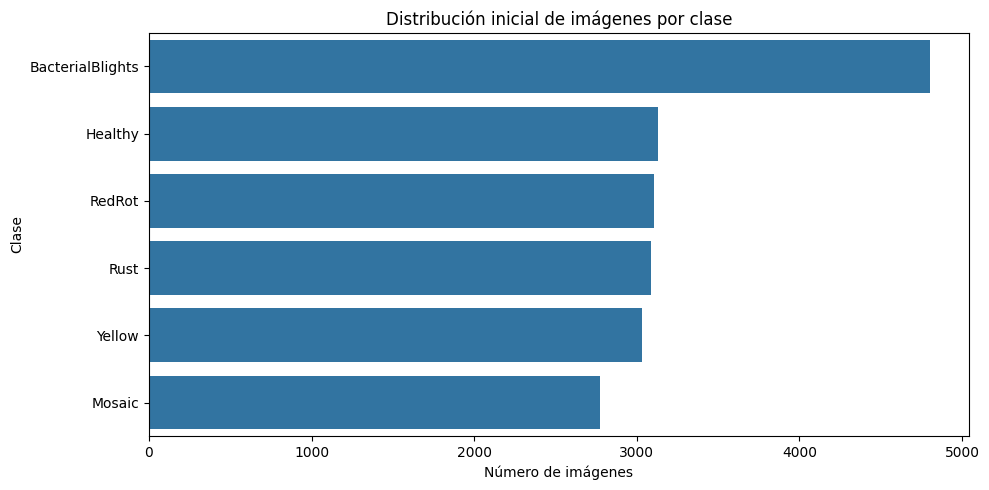

In [5]:
# ============================================================
# CELDA 5. EDA INICIAL DEL DATASET ORIGINAL
# ============================================================

df_inventory = build_inventory(RAW_DIR)

if df_inventory.empty:
    raise RuntimeError("No se encontraron imágenes en RAW_DIR. Verifica la descarga o la ruta del dataset.")

print("Total de imágenes originales:", len(df_inventory))
display(df_inventory.head())

class_counts_initial = (
    df_inventory.groupby("class")
    .size()
    .reset_index(name="n_images")
    .sort_values("n_images", ascending=False)
)
class_counts_initial["percentage"] = 100 * class_counts_initial["n_images"] / class_counts_initial["n_images"].sum()

display(class_counts_initial)

plt.figure(figsize=(10, 5))
sns.barplot(data=class_counts_initial, x="n_images", y="class")
plt.title("Distribución inicial de imágenes por clase")
plt.xlabel("Número de imágenes")
plt.ylabel("Clase")
plt.tight_layout()
plt.show()

## Celda 6 — Verificación de imágenes corruptas y duplicados exactos

Detecta imágenes ilegibles y duplicados exactos mediante MD5. Este paso debe realizarse antes de dividir el dataset para evitar fuga de información.

In [6]:
# ============================================================
# CELDA 6. VERIFICACIÓN DE CORRUPTAS Y DUPLICADOS
# ============================================================

image_paths = list_images(RAW_DIR)

# -----------------------------
# Imágenes corruptas
# -----------------------------
corrupt_rows = []
valid_paths = []

for img_path in image_paths:
    try:
        with Image.open(img_path) as img:
            img.verify()
        valid_paths.append(img_path)
    except Exception as e:
        corrupt_rows.append({"path": str(img_path), "error": str(e)})

df_corrupt = pd.DataFrame(corrupt_rows)
print("Imágenes corruptas:", len(df_corrupt))
if not df_corrupt.empty:
    display(df_corrupt.head())

# -----------------------------
# Duplicados exactos MD5
# -----------------------------
hash_rows = []
for img_path in valid_paths:
    hash_rows.append({
        "path": str(img_path),
        "class": img_path.parent.name,
        "hash": md5_file(img_path)
    })

df_hash = pd.DataFrame(hash_rows)
duplicate_mask = df_hash.duplicated(subset="hash", keep="first")
df_duplicates = df_hash[duplicate_mask].copy()

print("Imágenes válidas analizadas:", len(df_hash))
print("Hashes únicos:", df_hash["hash"].nunique())
print("Duplicados exactos detectados:", len(df_duplicates))

if not df_duplicates.empty:
    display(df_duplicates.head())

# Reportes de evidencia
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
df_corrupt.to_csv(REPORTS_DIR / "corrupt_images.csv", index=False)
df_duplicates.to_csv(REPORTS_DIR / "duplicate_images_md5.csv", index=False)

Imágenes corruptas: 0
Imágenes válidas analizadas: 19926
Hashes únicos: 19086
Duplicados exactos detectados: 840


,path,class,hash
4899,/content/datasets_raw/Healthy/cropped_healthy ...,Healthy,1b85752e0f120b71965ce2ce2335d628
4909,/content/datasets_raw/Healthy/cropped_healthy ...,Healthy,2e56117ca381e1c81bffe661a98d817b
4914,/content/datasets_raw/Healthy/cropped_healthy ...,Healthy,48f07fb16ea8fa5cd72edd6a99c7a57b
4915,/content/datasets_raw/Healthy/cropped_healthy ...,Healthy,2e91de65e14155babc7e078326feda2d
4916,/content/datasets_raw/Healthy/cropped_healthy ...,Healthy,1b85752e0f120b71965ce2ce2335d628


## Celda 7 — Limpieza controlada del dataset

Crea `CLEAN_DIR` conservando una sola copia de cada imagen válida. No borra el dataset original. Esta estrategia deja trazabilidad y permite reproducir el proceso.

In [7]:
# ============================================================
# CELDA 7. LIMPIEZA CONTROLADA DEL DATASET
# ============================================================

# Limpiar carpeta limpia previa para reproducibilidad.
if CLEAN_DIR.exists():
    shutil.rmtree(CLEAN_DIR)
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

# Conserva la primera ocurrencia de cada hash.
df_unique = df_hash.drop_duplicates(subset="hash", keep="first").copy()

for _, row in df_unique.iterrows():
    src = Path(row["path"])
    cls = row["class"]
    dst_dir = CLEAN_DIR / cls
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / src.name

    # Si existe un nombre repetido dentro de una clase, se renombra con hash corto.
    if dst.exists():
        dst = dst_dir / f"{src.stem}_{row['hash'][:8]}{src.suffix.lower()}"

    shutil.copy2(src, dst)

print("Imágenes originales:", len(df_inventory))
print("Imágenes corruptas excluidas:", len(df_corrupt))
print("Duplicados exactos excluidos:", len(df_duplicates))
print("Imágenes limpias:", len(list_images(CLEAN_DIR)))

cleaning_summary = {
    "original_images": int(len(df_inventory)),
    "corrupt_images": int(len(df_corrupt)),
    "duplicate_images_md5": int(len(df_duplicates)),
    "clean_images": int(len(list_images(CLEAN_DIR)))
}
save_json(cleaning_summary, REPORTS_DIR / "cleaning_summary.json")

Imágenes originales: 19926
Imágenes corruptas excluidas: 0
Duplicados exactos excluidos: 840
Imágenes limpias: 19086


## Celda 8 — EDA completo del dataset limpio

Analiza distribución final por clase, resolución, relación de aspecto, tamaño, brillo, contraste y estadísticas RGB. Estos resultados alimentan el capítulo de Materiales y Métodos.

Total imágenes limpias: 19086
Número de clases: 6
Imbalance ratio: 1.977


,class,n_images,percentage
0,BacterialBlights,4800,25.149324
3,RedRot,3108,16.284187
5,Yellow,2986,15.644975
1,Healthy,2948,15.445877
4,Rust,2816,14.754270
2,Mosaic,2428,12.721366


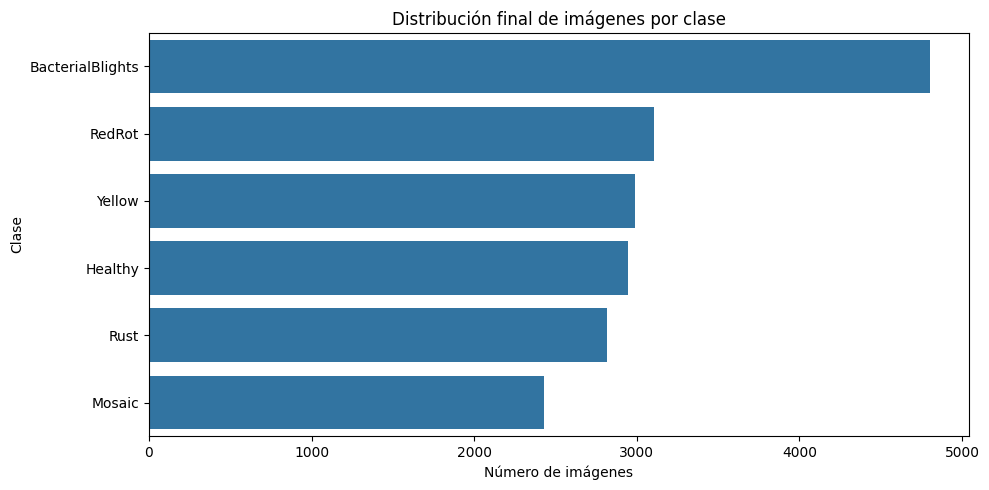

,width,height,aspect_ratio,size_kb
count,19086.000000,19086.000000,19086.000000,19086.000000
mean,498.625327,688.247459,0.864732,53.624575
std,266.425413,400.076872,0.426991,28.113437
min,180.000000,180.000000,0.350501,1.716797
25%,256.000000,256.000000,0.474760,35.622070
50%,493.000000,832.000000,0.750000,51.490234
75%,750.000000,1040.000000,1.000000,70.954590
max,1600.000000,1600.000000,3.058104,218.228516


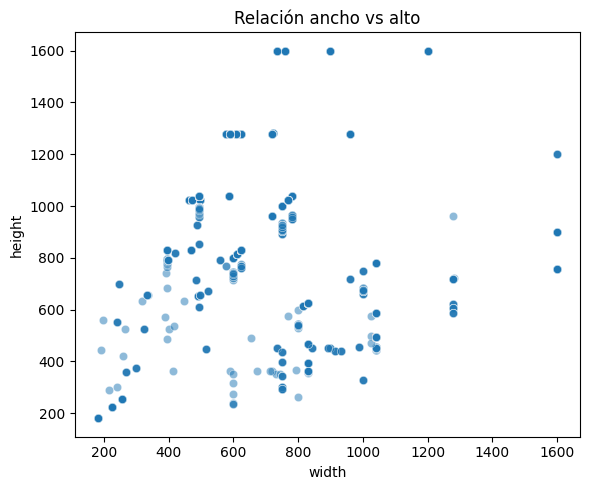

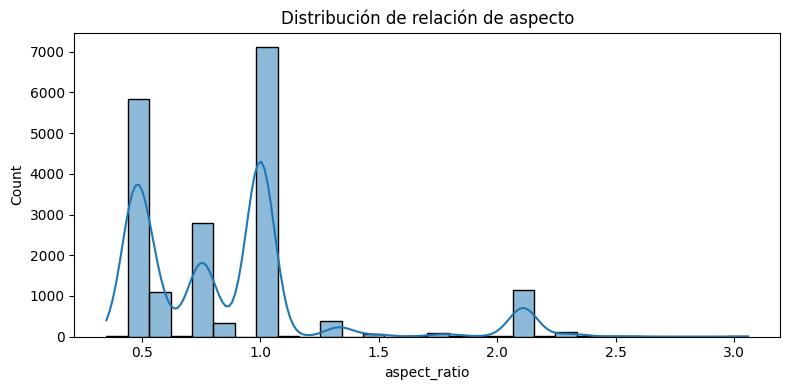

,r_mean,g_mean,b_mean,brightness,contrast
count,19086.000000,19086.000000,19086.000000,19086.000000,19086.000000
mean,0.456701,0.475140,0.387094,0.439645,0.170224
std,0.099940,0.107857,0.091291,0.091443,0.039384
min,0.062961,0.062964,0.062950,0.062958,0.019590
25%,0.398306,0.407391,0.328764,0.386369,0.142848
50%,0.470443,0.489169,0.387069,0.453310,0.170239
75%,0.526120,0.553925,0.447016,0.501964,0.197456
max,0.836352,0.836154,0.835980,0.836162,0.327095


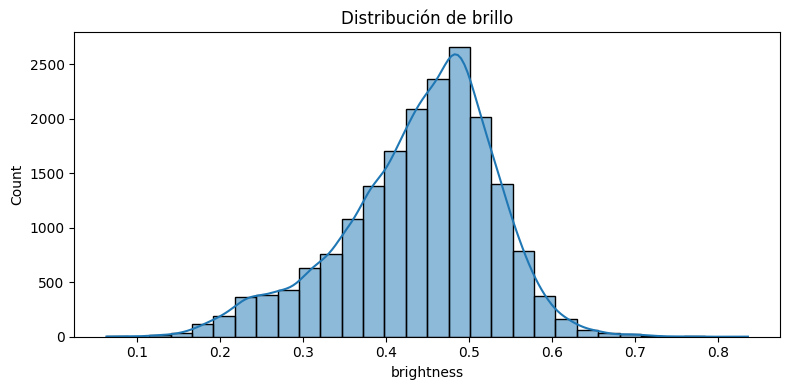

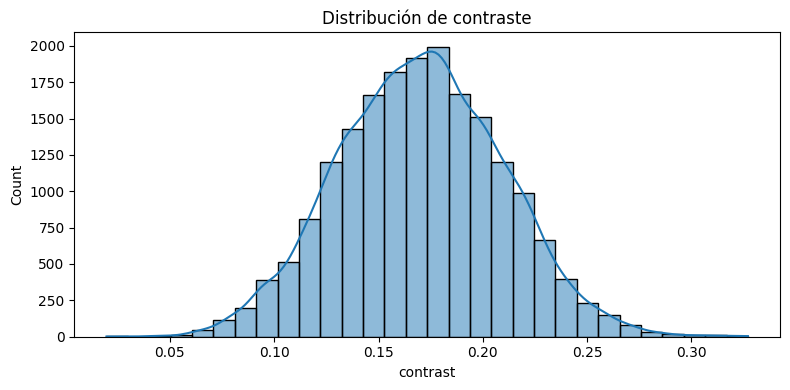

In [8]:
# ============================================================
# CELDA 8. EDA COMPLETO DEL DATASET LIMPIO
# ============================================================

df_clean = build_inventory(CLEAN_DIR)
if df_clean.empty:
    raise RuntimeError("CLEAN_DIR está vacío. Ejecuta primero la limpieza.")

# -----------------------------
# Distribución por clase
# -----------------------------
class_counts_clean = (
    df_clean.groupby("class")
    .size()
    .reset_index(name="n_images")
    .sort_values("n_images", ascending=False)
)
class_counts_clean["percentage"] = 100 * class_counts_clean["n_images"] / class_counts_clean["n_images"].sum()
imbalance_ratio = class_counts_clean["n_images"].max() / class_counts_clean["n_images"].min()

print("Total imágenes limpias:", len(df_clean))
print("Número de clases:", class_counts_clean.shape[0])
print("Imbalance ratio:", round(imbalance_ratio, 3))
display(class_counts_clean)

plt.figure(figsize=(10, 5))
sns.barplot(data=class_counts_clean, x="n_images", y="class")
plt.title("Distribución final de imágenes por clase")
plt.xlabel("Número de imágenes")
plt.ylabel("Clase")
plt.tight_layout()
plt.show()

# -----------------------------
# Resolución, aspecto, tamaño
# -----------------------------
size_rows = []
for img_path in list_images(CLEAN_DIR):
    try:
        with Image.open(img_path) as img:
            w, h = img.size
        size_rows.append({
            "path": str(img_path),
            "class": img_path.parent.name,
            "width": w,
            "height": h,
            "aspect_ratio": w / h if h else np.nan,
            "size_kb": img_path.stat().st_size / 1024
        })
    except Exception:
        pass

df_sizes = pd.DataFrame(size_rows)
display(df_sizes[["width", "height", "aspect_ratio", "size_kb"]].describe())

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_sizes, x="width", y="height", alpha=0.5)
plt.title("Relación ancho vs alto")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_sizes["aspect_ratio"], bins=30, kde=True)
plt.title("Distribución de relación de aspecto")
plt.tight_layout()
plt.show()

# -----------------------------
# RGB, brillo y contraste
# -----------------------------
color_rows = []
for img_path in list_images(CLEAN_DIR):
    try:
        with Image.open(img_path).convert("RGB") as img:
            arr = np.asarray(img.resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32) / 255.0
        gray = arr.mean(axis=2)
        color_rows.append({
            "path": str(img_path),
            "class": img_path.parent.name,
            "r_mean": arr[:, :, 0].mean(),
            "g_mean": arr[:, :, 1].mean(),
            "b_mean": arr[:, :, 2].mean(),
            "brightness": gray.mean(),
            "contrast": gray.std()
        })
    except Exception:
        pass

df_color = pd.DataFrame(color_rows)
display(df_color[["r_mean", "g_mean", "b_mean", "brightness", "contrast"]].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df_color["brightness"], bins=30, kde=True)
plt.title("Distribución de brillo")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_color["contrast"], bins=30, kde=True)
plt.title("Distribución de contraste")
plt.tight_layout()
plt.show()

# Guardar tablas del EDA
class_counts_clean.to_csv(REPORTS_DIR / "class_distribution_clean.csv", index=False)
df_sizes.to_csv(REPORTS_DIR / "image_size_statistics.csv", index=False)
df_color.to_csv(REPORTS_DIR / "color_brightness_contrast_statistics.csv", index=False)

## Celda 9 — Ejemplos visuales representativos por clase

Muestra una imagen por categoría diagnóstica. Esta figura puede usarse como apoyo visual en el documento final.

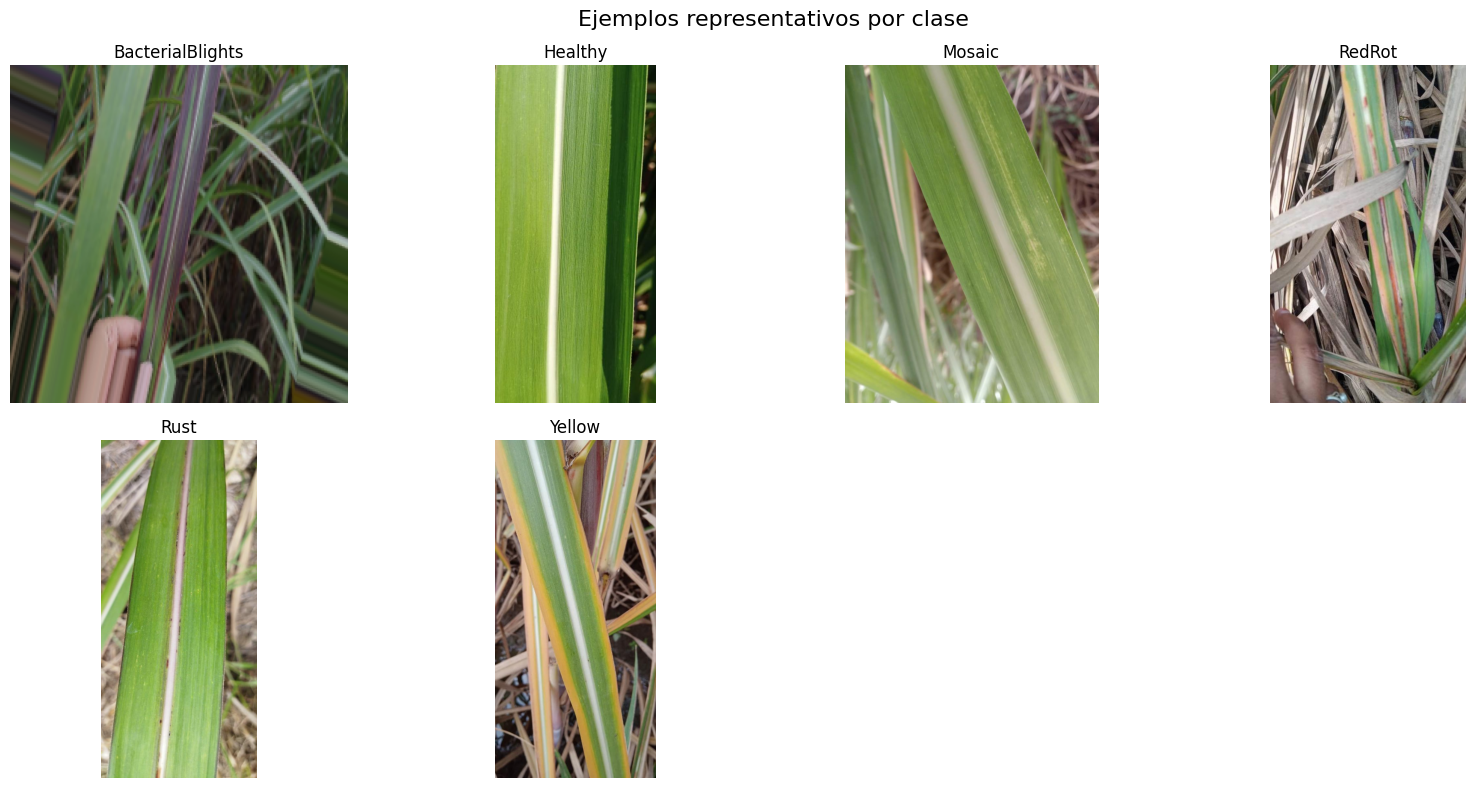

In [9]:
# ============================================================
# CELDA 9. EJEMPLOS VISUALES REPRESENTATIVOS POR CLASE
# ============================================================

classes_clean = sorted(df_clean["class"].unique())
n_classes_clean = len(classes_clean)
cols = 4
rows = int(np.ceil(n_classes_clean / cols))

plt.figure(figsize=(cols * 4, rows * 4))
for i, cls in enumerate(classes_clean, 1):
    imgs = list_images(CLEAN_DIR / cls)
    if not imgs:
        continue
    img_path = random.choice(imgs)
    img = Image.open(img_path).convert("RGB")
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Ejemplos representativos por clase", fontsize=16)
plt.tight_layout()
plt.show()

## Celda 10 — Normalización a formato `train/val/test/class`

Adapta el dataset limpio al formato estándar requerido por `torchvision.datasets.ImageFolder` y YOLO Classification. Si el dataset ya trae particiones, las respeta; si solo trae carpetas por clase, crea split estratificado 70/15/15 por clase.

In [10]:
# ============================================================
# CELDA 10. NORMALIZAR DATASET A TRAIN / VAL / TEST / CLASS
# ============================================================

source = CLEAN_DIR

if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)
for split in ["train", "val", "test"]:
    (DATA_DIR / split).mkdir(parents=True, exist_ok=True)

train_src = pick_dir(source, ["train"])
val_src = pick_dir(source, ["val", "valid", "validation"])
test_src = pick_dir(source, ["test"])

if train_src is not None and (val_src is not None or test_src is not None):
    print("Dataset con particiones detectadas. Se copiará manteniendo estructura.")

    def copy_split(src_split, dst_split_name):
        if src_split is None:
            return
        class_dirs = [d for d in src_split.iterdir() if d.is_dir() and len(list_images(d)) > 0]
        for cls_dir in sorted(class_dirs):
            copy_images(list_images(cls_dir), DATA_DIR / dst_split_name / cls_dir.name)

    copy_split(train_src, "train")
    copy_split(val_src, "val")
    copy_split(test_src, "test")

else:
    print("Dataset sin particiones detectadas. Se creará split 70/15/15 por clase.")

    class_dirs = [d for d in source.iterdir() if d.is_dir() and len(list_images(d)) > 0]
    if not class_dirs:
        raise RuntimeError("No se detectaron carpetas de clases con imágenes en CLEAN_DIR.")

    for cls_dir in sorted(class_dirs):
        imgs = list_images(cls_dir)
        if len(imgs) < 3:
            print(f"Advertencia: clase {cls_dir.name} con menos de 3 imágenes. Se omite split estándar.")
            copy_images(imgs, DATA_DIR / "train" / cls_dir.name)
            continue

        tr, tmp = train_test_split(imgs, test_size=0.30, random_state=SEED, shuffle=True)
        va, te = train_test_split(tmp, test_size=0.50, random_state=SEED, shuffle=True)

        copy_images(tr, DATA_DIR / "train" / cls_dir.name)
        copy_images(va, DATA_DIR / "val" / cls_dir.name)
        copy_images(te, DATA_DIR / "test" / cls_dir.name)

# Resumen por clase y split
rows = []
for split in ["train", "val", "test"]:
    for cls_dir in sorted([d for d in (DATA_DIR / split).iterdir() if d.is_dir()]):
        rows.append({
            "split": split,
            "class": cls_dir.name,
            "n_images": len(list_images(cls_dir))
        })

df_counts = pd.DataFrame(rows)
if df_counts.empty:
    raise RuntimeError("No se copiaron imágenes a DATA_DIR.")

tabla_split = df_counts.pivot(index="class", columns="split", values="n_images").fillna(0).astype(int)
display(tabla_split)

df_counts.to_csv(REPORTS_DIR / "split_distribution.csv", index=False)
print("DATA_DIR listo:", DATA_DIR)
print("Total imágenes organizadas:", df_counts["n_images"].sum())

Dataset sin particiones detectadas. Se creará split 70/15/15 por clase.


split,test,train,val
class,,,
BacterialBlights,720,3360,720
Healthy,443,2063,442
Mosaic,365,1699,364
RedRot,467,2175,466
Rust,423,1971,422
Yellow,448,2090,448


DATA_DIR listo: /content/SugarcaneLeafImageDataset19k/dataset_train_val_test
Total imágenes organizadas: 19086


## Celda 11 — Verificación de fuga de información entre splits

Comprueba que no existan imágenes duplicadas exactas entre `train`, `val` y `test`. El resultado esperado es cero duplicados cruzados.

In [11]:
# ============================================================
# CELDA 11. VERIFICACIÓN DE FUGA ENTRE SPLITS
# ============================================================

split_hash_rows = []
for split in ["train", "val", "test"]:
    for img_path in list_images(DATA_DIR / split):
        split_hash_rows.append({
            "split": split,
            "class": img_path.parent.name,
            "path": str(img_path),
            "hash": md5_file(img_path)
        })

df_split_hash = pd.DataFrame(split_hash_rows)

leak_rows = []
for h, g in df_split_hash.groupby("hash"):
    splits = sorted(g["split"].unique())
    if len(splits) > 1:
        leak_rows.append({
            "hash": h,
            "splits": ",".join(splits),
            "n_files": len(g),
            "paths": " | ".join(g["path"].tolist())
        })

df_leakage = pd.DataFrame(leak_rows)
print("Duplicados exactos entre splits:", len(df_leakage))
if not df_leakage.empty:
    display(df_leakage.head())

df_leakage.to_csv(REPORTS_DIR / "split_leakage_md5.csv", index=False)

Duplicados exactos entre splits: 0


## Celda 12 — DataLoaders para modelos PyTorch

Crea transformaciones, datasets, loaders, metadatos de clases y pesos de clase para mitigar desbalance durante el entrenamiento.

In [12]:
# ============================================================
# CELDA 12. DATALOADERS PARA PYTORCH
# ============================================================

train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(DATA_DIR / "train", transform=train_tf)
val_ds = datasets.ImageFolder(DATA_DIR / "val", transform=eval_tf)
test_ds = datasets.ImageFolder(DATA_DIR / "test", transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))

class_names = train_ds.classes
class_to_idx = train_ds.class_to_idx
num_classes = len(class_names)

counts = np.bincount(train_ds.targets, minlength=num_classes)
class_weights_np = counts.sum() / np.maximum(counts, 1)
class_weights_np = class_weights_np / class_weights_np.mean()
class_weights = torch.tensor(class_weights_np, dtype=torch.float32)

print("Clases:", class_names)
print("Número de clases:", num_classes)
print("Mapeo clase → índice:", class_to_idx)
print("Imágenes train por clase:", counts.tolist())
print("Pesos de clase:", class_weights.tolist())

Clases: ['BacterialBlights', 'Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow']
Número de clases: 6
Mapeo clase → índice: {'BacterialBlights': 0, 'Healthy': 1, 'Mosaic': 2, 'RedRot': 3, 'Rust': 4, 'Yellow': 5}
Imágenes train por clase: [3360, 2063, 1699, 2175, 1971, 2090]
Pesos de clase: [0.6340128183364868, 1.0326141119003296, 1.25384521484375, 0.979440450668335, 1.0808132886886597, 1.019274115562439]


## Celda 13 — Funciones para listas de imágenes de validación y prueba

Crea listas de rutas y etiquetas reales para evaluar modelos YOLO, ya que YOLO trabaja directamente con rutas de imágenes.

In [13]:
# ============================================================
# CELDA 13. LISTAS DE IMÁGENES PARA VALIDACIÓN Y TEST
# ============================================================

def collect_split_paths(split_name: str):
    """Retorna rutas de imágenes y etiquetas numéricas para un split."""
    image_paths, y = [], []
    for cls in class_names:
        cls_dir = DATA_DIR / split_name / cls
        for p in list_images(cls_dir):
            image_paths.append(str(p))
            y.append(class_to_idx[cls])
    return image_paths, np.array(y)

val_image_paths, val_y = collect_split_paths("val")
test_image_paths, test_y = collect_split_paths("test")

print("Imágenes validation:", len(val_image_paths))
print("Imágenes test:", len(test_image_paths))

Imágenes validation: 2862
Imágenes test: 2866


## Celda 14 — Definición de modelos PyTorch y funciones de entrenamiento/evaluación

Define la CNN base, el constructor de arquitecturas preentrenadas, las métricas, la función de predicción y el entrenamiento con early stopping.

In [14]:
# ============================================================
# CELDA 14. MODELOS Y FUNCIONES PYTORCH
# ============================================================

class SimpleCNN(nn.Module):
    """CNN base construida desde cero para comparación con modelos preentrenados."""
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.35), nn.Linear(256, n_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


def build_torch_model(model_key: str, n_classes: int):
    """Construye el modelo solicitado y adapta su capa final al número de clases."""
    if model_key == "simple_cnn":
        return SimpleCNN(n_classes)

    if model_key == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, n_classes)
        return m

    if model_key == "mobilenet_v3_large":
        m = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, n_classes)
        return m

    if model_key == "regnet_y_3_2gf":
        m = models.regnet_y_3_2gf(weights=models.RegNet_Y_3_2GF_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, n_classes)
        return m

    if model_key == "ViT-B/16":
        try:
            return timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=n_classes)
        except Exception:
            m = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
            m.heads.head = nn.Linear(m.heads.head.in_features, n_classes)
            return m

    if model_key == "hybrid_cnn_transformer":
        try:
            return timm.create_model("mobilevit_s", pretrained=True, num_classes=n_classes)
        except Exception:
            return timm.create_model("mobilevitv2_100", pretrained=True, num_classes=n_classes)

    raise ValueError(f"Modelo no soportado: {model_key}")


def count_params(model):
    """Cuenta parámetros entrenables y no entrenables del modelo."""
    return sum(p.numel() for p in model.parameters())


def metrics_from_probs(y_true, probs):
    """Calcula top1, top5, precisión macro, recall macro y F1 macro."""
    y_pred = probs.argmax(axis=1)
    top1 = accuracy_score(y_true, y_pred)
    k = min(5, probs.shape[1])
    topk = np.argpartition(probs, -k, axis=1)[:, -k:]
    top5 = np.mean([y_true[i] in topk[i] for i in range(len(y_true))])
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "top1": float(top1),
        "top5": float(top5),
        "macro_precision": float(p),
        "macro_recall": float(r),
        "macro_f1": float(f1),
    }, y_pred


@torch.no_grad()
def predict_torch(model, loader):
    """Genera probabilidades para todas las imágenes de un DataLoader."""
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        ps.append(probs)
        ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(ps)


def train_torch_model(model_key, out_dir, epochs=12, lr=3e-4, wd=1e-4, patience=6, init_ckpt=None):
    """Entrena un modelo PyTorch y guarda best.pt, last.pt, history.csv y train_config.json."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    model = build_torch_model(model_key, num_classes).to(DEVICE)

    if init_ckpt is not None and Path(init_ckpt).exists():
        ckpt = torch.load(init_ckpt, map_location=DEVICE)
        state = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
        model.load_state_dict(state, strict=False)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))
    scaler = GradScaler("cuda", enabled=(DEVICE == "cuda"))

    best_val_loss = float("inf")
    bad_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=(DEVICE == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * x.size(0)
            train_correct += (logits.argmax(1) == y).sum().item()
            train_total += x.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(DEVICE, non_blocking=True)
                y = y.to(DEVICE, non_blocking=True)
                logits = model(x)
                loss = criterion(logits, y)
                val_loss += loss.item() * x.size(0)
                val_correct += (logits.argmax(1) == y).sum().item()
                val_total += x.size(0)

        scheduler.step()

        train_loss /= max(train_total, 1)
        val_loss /= max(val_total, 1)
        train_acc = train_correct / max(train_total, 1)
        val_acc = val_correct / max(val_total, 1)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"]
        })

        torch.save({"state_dict": model.state_dict(), "model_key": model_key, "num_classes": num_classes, "class_names": class_names}, out_dir / "last.pt")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            bad_epochs = 0
            torch.save({"state_dict": model.state_dict(), "model_key": model_key, "num_classes": num_classes, "class_names": class_names}, out_dir / "best.pt")
        else:
            bad_epochs += 1

        print(f"[{model_key}] Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

        if bad_epochs >= patience:
            print(f"[{model_key}] Early stopping activado.")
            break

    pd.DataFrame(history).to_csv(out_dir / "history.csv", index=False)
    save_json({"model_key": model_key, "epochs": epochs, "lr": lr, "wd": wd, "patience": patience, "best_val_loss": best_val_loss}, out_dir / "train_config.json")
    return out_dir / "best.pt"

## Celda 15 — Funciones de predicción para YOLO Classification

Permite obtener probabilidades por clase en validation o test, usando rutas de imágenes.

In [15]:
# ============================================================
# CELDA 15. FUNCIONES YOLO CLASSIFICATION
# ============================================================

def predict_yolo_probs(model, image_paths, batch=64):
    """Genera probabilidades por clase con un modelo YOLO de clasificación."""
    results = model.predict(
        source=image_paths,
        imgsz=IMG_SIZE,
        batch=batch,
        device=0 if DEVICE == "cuda" else "cpu",
        verbose=False
    )
    probs = []
    for r in results:
        if r.probs is None:
            probs.append(np.ones(num_classes) / num_classes)
        else:
            probs.append(r.probs.data.cpu().numpy())
    return np.array(probs)

## Celda 16 — Screening de modelos PyTorch en validation

Entrena seis arquitecturas PyTorch y las evalúa únicamente en el conjunto de validación. El test permanece reservado para la evaluación final.

In [16]:
# ============================================================
# CELDA 16. SCREENING DE MODELOS PYTORCH EN VALIDATION
# ============================================================

TORCH_MODELS = [
    "simple_cnn",
    "resnet50",
    "ViT-B/16",
    "hybrid_cnn_transformer",
    "mobilenet_v3_large",
    "regnet_y_3_2gf",
]

# SCREEN_EPOCHS_TORCH se definió en la configuración global.
screen_torch_rows = []

for model_key in TORCH_MODELS:
    print(f"\n===== SCREENING PYTORCH: {model_key} =====")
    out_dir = EXP_ROOT / "screen" / "torch" / model_key
    start_time = time.time()

    best_ckpt = train_torch_model(
        model_key=model_key,
        out_dir=out_dir,
        epochs=SCREEN_EPOCHS_TORCH,
        lr=3e-4,
        wd=1e-4,
        patience=5
    )

    model = build_torch_model(model_key, num_classes).to(DEVICE)
    ckpt = torch.load(best_ckpt, map_location=DEVICE)
    model.load_state_dict(ckpt["state_dict"], strict=False)

    y_true, probs = predict_torch(model, val_loader)
    metrics, y_pred = metrics_from_probs(y_true, probs)

    report = classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0)
    (out_dir / "classification_report_val.txt").write_text(report, encoding="utf-8")

    screen_torch_rows.append({
        "framework": "torch",
        "model_id": model_key,
        "evaluation_split": "validation",
        "params_M": round(count_params(model) / 1e6, 3),
        "screen_minutes": round((time.time() - start_time) / 60, 2),
        "ckpt_path": str(best_ckpt),
        **metrics
    })

    del model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

df_screen_torch = pd.DataFrame(screen_torch_rows).sort_values(["macro_f1", "top1"], ascending=False).reset_index(drop=True)
df_screen_torch.to_csv(EXP_ROOT / "leaderboard_screen_torch_val.csv", index=False)
display(df_screen_torch)


===== SCREENING PYTORCH: simple_cnn =====
[simple_cnn] Epoch 01/1 | train_loss=1.2345 | val_loss=1.0470 | val_acc=0.6468

===== SCREENING PYTORCH: resnet50 =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 236MB/s]


[resnet50] Epoch 01/1 | train_loss=0.6136 | val_loss=0.4957 | val_acc=0.9022

===== SCREENING PYTORCH: ViT-B/16 =====


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

[ViT-B/16] Epoch 01/1 | train_loss=1.2830 | val_loss=0.8093 | val_acc=0.7551


...

100%|██████████| 21.1M/21.1M [00:00<00:00, 191MB/s]


[mobilenet_v3_large] Epoch 01/1 | train_loss=0.5878 | val_loss=0.5356 | val_acc=0.8927

===== SCREENING PYTORCH: regnet_y_3_2gf =====
Downloading: "https://download.pytorch.org/models/regnet_y_3_2gf-9180c971.pth" to /root/.cache/torch/hub/checkpoints/regnet_y_3_2gf-9180c971.pth


100%|██████████| 74.6M/74.6M [00:00<00:00, 240MB/s]


[regnet_y_3_2gf] Epoch 01/1 | train_loss=0.5569 | val_loss=0.4223 | val_acc=0.9364


,framework,model_id,evaluation_split,params_M,screen_minutes,ckpt_path,top1,top5,macro_precision,macro_recall,macro_f1
0,torch,regnet_y_3_2gf,validation,17.932,3.66,/content/SugarcaneLeafImageDataset19k/experime...,0.936408,0.999651,0.932037,0.928461,0.929784
1,torch,hybrid_cnn_transformer,validation,4.941,3.18,/content/SugarcaneLeafImageDataset19k/experime...,0.918588,0.998952,0.911541,0.915252,0.912641
2,torch,resnet50,validation,23.520,2.84,/content/SugarcaneLeafImageDataset19k/experime...,0.902166,0.996506,0.899705,0.891499,0.892627
3,torch,mobilenet_v3_large,validation,4.210,3.70,/content/SugarcaneLeafImageDataset19k/experime...,0.892732,0.997904,0.888036,0.884882,0.881456
4,torch,ViT-B/16,validation,85.803,1.58,/content/SugarcaneLeafImageDataset19k/experime...,0.755066,0.994060,0.773712,0.726495,0.733360
5,torch,simple_cnn,validation,0.391,1.88,/content/SugarcaneLeafImageDataset19k/experime...,0.646751,0.992662,0.650992,0.622017,0.619198


## Celda 17 — Screening de YOLO Classification en validation

Entrena YOLOv8, YOLO11 y YOLO26 para clasificación y los evalúa sobre validation. Así se mantiene una comparación justa con los modelos PyTorch.

In [17]:
# ============================================================
# CELDA 17. SCREENING DE YOLO EN VALIDATION
# ============================================================

YOLO_MODELS = [
    "yolov8n-cls.pt",
    "yolo11n-cls.pt",
    "yolo26n-cls.pt"
]

# SCREEN_EPOCHS_YOLO se definió en la configuración global.
screen_yolo_rows = []
yolo_project = EXP_ROOT / "screen" / "yolo_runs"
yolo_project.mkdir(parents=True, exist_ok=True)

for model_name in YOLO_MODELS:
    print(f"\n===== SCREENING YOLO: {model_name} =====")
    run_name = f"{Path(model_name).stem}_screen"
    start_time = time.time()

    model = YOLO(model_name)
    model.train(
        data=str(DATA_DIR),
        epochs=SCREEN_EPOCHS_YOLO,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        patience=8,
        workers=NUM_WORKERS,
        device=0 if DEVICE == "cuda" else "cpu",
        project=str(yolo_project),
        name=run_name,
        exist_ok=True
    )

    run_dir = Path(model.trainer.save_dir)
    best_ckpt = Path(model.trainer.best)
    best_model = YOLO(str(best_ckpt))

    probs = predict_yolo_probs(best_model, val_image_paths, batch=64)
    metrics, y_pred = metrics_from_probs(val_y, probs)

    n_params = int(sum(p.numel() for p in best_model.model.parameters()))
    report = classification_report(val_y, y_pred, target_names=class_names, digits=4, zero_division=0)
    (run_dir / "classification_report_val.txt").write_text(report, encoding="utf-8")

    screen_yolo_rows.append({
        "framework": "yolo",
        "model_id": model_name,
        "evaluation_split": "validation",
        "params_M": round(n_params / 1e6, 3),
        "screen_minutes": round((time.time() - start_time) / 60, 2),
        "ckpt_path": str(best_ckpt),
        **metrics
    })

    del model, best_model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

df_screen_yolo = pd.DataFrame(screen_yolo_rows).sort_values(["macro_f1", "top1"], ascending=False).reset_index(drop=True)
df_screen_yolo.to_csv(EXP_ROOT / "leaderboard_screen_yolo_val.csv", index=False)
display(df_screen_yolo)


===== SCREENING YOLO: yolov8n-cls.pt =====
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/SugarcaneLeafImageDataset19k/dataset_train_val_test, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n-cls_scr

,framework,model_id,evaluation_split,params_M,screen_minutes,ckpt_path,top1,top5,macro_precision,macro_recall,macro_f1
0,yolo,yolov8n-cls.pt,validation,1.443,5.51,/content/SugarcaneLeafImageDataset19k/experime...,0.864430,0.997205,0.861358,0.850332,0.854940
1,yolo,yolo11n-cls.pt,validation,1.534,3.82,/content/SugarcaneLeafImageDataset19k/experime...,0.860238,0.993361,0.854897,0.844857,0.846885
2,yolo,yolo26n-cls.pt,validation,1.534,1.99,/content/SugarcaneLeafImageDataset19k/experime...,0.849406,0.992662,0.852340,0.829486,0.833004


## Celda 18 — Leaderboard global y selección Top-K

Une los resultados de PyTorch y YOLO, ordena por F1 macro y selecciona los mejores modelos para la etapa de fine-tuning.

In [18]:
# ============================================================
# CELDA 18. LEADERBOARD GLOBAL Y TOP-K
# ============================================================
# Une resultados de PyTorch y YOLO, evaluados únicamente sobre validation.
# El conjunto test NO se usa aquí.

torch_path = EXP_ROOT / "leaderboard_screen_torch_val.csv"
yolo_path = EXP_ROOT / "leaderboard_screen_yolo_val.csv"

if not torch_path.exists() or not yolo_path.exists():
    raise FileNotFoundError("Faltan leaderboards de screening. Ejecuta las celdas 16 y 17.")

df_screen_torch = pd.read_csv(torch_path)
df_screen_yolo = pd.read_csv(yolo_path)

df_screen_all = pd.concat([df_screen_torch, df_screen_yolo], ignore_index=True)
df_screen_all = df_screen_all.sort_values(["macro_f1", "top1"], ascending=False).reset_index(drop=True)

top_models = df_screen_all.head(TOP_K).copy()

df_screen_all.to_csv(EXP_ROOT / "leaderboard_screen_global_val.csv", index=False)
top_models.to_csv(EXP_ROOT / "top_models_for_final.csv", index=False)

display(df_screen_all)
print("Modelos seleccionados para fine-tuning:")
display(top_models)

,framework,model_id,evaluation_split,params_M,screen_minutes,ckpt_path,top1,top5,macro_precision,macro_recall,macro_f1
0,torch,regnet_y_3_2gf,validation,17.932,3.66,/content/SugarcaneLeafImageDataset19k/experime...,0.936408,0.999651,0.932037,0.928461,0.929784
1,torch,hybrid_cnn_transformer,validation,4.941,3.18,/content/SugarcaneLeafImageDataset19k/experime...,0.918588,0.998952,0.911541,0.915252,0.912641
2,torch,resnet50,validation,23.520,2.84,/content/SugarcaneLeafImageDataset19k/experime...,0.902166,0.996506,0.899705,0.891499,0.892627
3,torch,mobilenet_v3_large,validation,4.210,3.70,/content/SugarcaneLeafImageDataset19k/experime...,0.892732,0.997904,0.888036,0.884882,0.881456
4,yolo,yolov8n-cls.pt,validation,1.443,5.51,/content/SugarcaneLeafImageDataset19k/experime...,0.864430,0.997205,0.861358,0.850332,0.854940
5,yolo,yolo11n-cls.pt,validation,1.534,3.82,/content/SugarcaneLeafImageDataset19k/experime...,0.860238,0.993361,0.854897,0.844857,0.846885
6,yolo,yolo26n-cls.pt,validation,1.534,1.99,/content/SugarcaneLeafImageDataset19k/experime...,0.849406,0.992662,0.852340,0.829486,0.833004
7,torch,ViT-B/16,validation,85.803,1.58,/content/SugarcaneLeafImageDataset19k/experime...,0.755066,0.994060,0.773712,0.726495,0.733360
8,torch,simple_cnn,validation,0.391,1.88,/content/SugarcaneLeafImageDataset19k/experime...,0.646751,0.992662,0.650992,0.622017,0.619198


Modelos seleccionados para fine-tuning:


,framework,model_id,evaluation_split,params_M,screen_minutes,ckpt_path,top1,top5,macro_precision,macro_recall,macro_f1
0,torch,regnet_y_3_2gf,validation,17.932,3.66,/content/SugarcaneLeafImageDataset19k/experime...,0.936408,0.999651,0.932037,0.928461,0.929784
1,torch,hybrid_cnn_transformer,validation,4.941,3.18,/content/SugarcaneLeafImageDataset19k/experime...,0.918588,0.998952,0.911541,0.915252,0.912641
2,torch,resnet50,validation,23.520,2.84,/content/SugarcaneLeafImageDataset19k/experime...,0.902166,0.996506,0.899705,0.891499,0.892627


## Celda 19 — Fine-tuning de Top-K y evaluación final en test

Reentrena o afina los modelos seleccionados desde los checkpoints del screening. Durante el entrenamiento se usa train/validation; al finalizar se evalúa una sola vez en test.

In [19]:
# ============================================================
# CELDA 19. FINE-TUNING TOP-K Y EVALUACIÓN FINAL EN TEST
# ============================================================
# Toma los Top-K seleccionados con validation, continúa su entrenamiento
# y realiza la evaluación final una sola vez sobre test.
# También guarda un best.pt canónico del mejor modelo final en BEST_MODEL_DIR.

final_rows = []

for _, row in top_models.iterrows():
    fw = row["framework"]
    model_id = row["model_id"]
    init_ckpt = row["ckpt_path"]

    print(f"\n===== FINAL: {fw} | {model_id} =====")
    start_time = time.time()

    if fw == "torch":
        out_dir = EXP_ROOT / "final" / "torch" / model_id
        best_ckpt = train_torch_model(
            model_key=model_id,
            out_dir=out_dir,
            epochs=FINAL_EPOCHS_TORCH,
            lr=1e-4,
            wd=1e-4,
            patience=8,
            init_ckpt=init_ckpt
        )

        model = build_torch_model(model_id, num_classes).to(DEVICE)
        ckpt = torch.load(best_ckpt, map_location=DEVICE)
        model.load_state_dict(ckpt["state_dict"], strict=False)

        y_true, probs = predict_torch(model, test_loader)
        metrics, y_pred = metrics_from_probs(y_true, probs)

        report = classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0)
        (out_dir / "classification_report_test.txt").write_text(report, encoding="utf-8")
        np.save(out_dir / "test_probs.npy", probs)
        np.save(out_dir / "test_y_true.npy", y_true)
        np.save(out_dir / "test_y_pred.npy", y_pred)

        ts_path, onnx_path = None, None
        model_cpu = model.cpu().eval()
        dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

        try:
            traced = torch.jit.trace(model_cpu, dummy)
            ts_path = out_dir / "best.torchscript"
            traced.save(str(ts_path))
        except Exception as e:
            ts_path = f"ERROR: {e}"

        try:
            import onnx
            import onnxscript
            onnx_path = out_dir / "best.onnx"
            torch.onnx.export(
                model_cpu,
                dummy,
                str(onnx_path),
                input_names=["images"],
                output_names=["logits"],
                opset_version=17
            )
        except Exception as e:
            onnx_path = f"ERROR: {e}"

        final_rows.append({
            "framework": fw,
            "model_id": model_id,
            "best_ckpt": str(best_ckpt),
            "export_torchscript": str(ts_path),
            "export_onnx": str(onnx_path),
            "final_minutes": round((time.time() - start_time) / 60, 2),
            **metrics
        })

        del model, model_cpu
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    else:
        yolo_final_project = EXP_ROOT / "final" / "yolo_runs"
        yolo_final_project.mkdir(parents=True, exist_ok=True)

        model = YOLO(init_ckpt)
        run_name = f"{Path(model_id).stem}_final"
        model.train(
            data=str(DATA_DIR),
            epochs=FINAL_EPOCHS_YOLO,
            imgsz=IMG_SIZE,
            batch=BATCH_SIZE,
            patience=12,
            workers=NUM_WORKERS,
            device=0 if DEVICE == "cuda" else "cpu",
            project=str(yolo_final_project),
            name=run_name,
            exist_ok=True
        )

        run_dir = Path(model.trainer.save_dir)
        best_ckpt = Path(model.trainer.best)
        best_model = YOLO(str(best_ckpt))

        probs = predict_yolo_probs(best_model, test_image_paths, batch=64)
        metrics, y_pred = metrics_from_probs(test_y, probs)

        report = classification_report(test_y, y_pred, target_names=class_names, digits=4, zero_division=0)
        (run_dir / "classification_report_test.txt").write_text(report, encoding="utf-8")
        np.save(run_dir / "test_probs.npy", probs)
        np.save(run_dir / "test_y_true.npy", test_y)
        np.save(run_dir / "test_y_pred.npy", y_pred)

        try:
            onnx_path = best_model.export(format="onnx", imgsz=IMG_SIZE)
        except Exception as e:
            onnx_path = f"ERROR: {e}"

        try:
            ts_path = best_model.export(format="torchscript", imgsz=IMG_SIZE)
        except Exception as e:
            ts_path = f"ERROR: {e}"

        final_rows.append({
            "framework": fw,
            "model_id": model_id,
            "best_ckpt": str(best_ckpt),
            "export_torchscript": str(ts_path),
            "export_onnx": str(onnx_path),
            "final_minutes": round((time.time() - start_time) / 60, 2),
            **metrics
        })

        del model, best_model
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

df_final = pd.DataFrame(final_rows).sort_values(["macro_f1", "top1"], ascending=False).reset_index(drop=True)
df_final.to_csv(EXP_ROOT / "leaderboard_final_test.csv", index=False)
display(df_final)

if df_final.empty:
    raise RuntimeError("No hay resultados finales. Revisa el entrenamiento final.")

best_final = df_final.iloc[0].to_dict()
best_ckpt_source = Path(best_final["best_ckpt"])
canonical_best = BEST_MODEL_DIR / "best.pt"

if best_ckpt_source.exists():
    shutil.copy2(best_ckpt_source, canonical_best)
    print("best.pt canónico guardado en:", canonical_best)
else:
    print("Advertencia: no se encontró el checkpoint del mejor modelo:", best_ckpt_source)

save_json({
    "best_model": best_final,
    "canonical_best_pt": str(canonical_best),
    "class_names": class_names,
    "class_to_idx": class_to_idx,
    "img_size": IMG_SIZE,
    "screening_split": "validation",
    "final_split": "test"
}, BEST_MODEL_DIR / "best_model_metadata.json")


===== FINAL: torch | regnet_y_3_2gf =====
[regnet_y_3_2gf] Epoch 01/1 | train_loss=0.3654 | val_loss=0.3797 | val_acc=0.9511


W0610 16:16:27.250000 17733 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `RegNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `RegNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

...

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


,framework,model_id,best_ckpt,export_torchscript,export_onnx,final_minutes,top1,top5,macro_precision,macro_recall,macro_f1
0,torch,regnet_y_3_2gf,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,2.10,0.950454,0.998604,0.945572,0.946255,0.945835
1,torch,resnet50,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,1.87,0.934403,0.997558,0.927640,0.929423,0.928304
2,torch,hybrid_cnn_transformer,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,1.98,0.933357,0.998255,0.926624,0.926152,0.926191


best.pt canónico guardado en: /content/SugarcaneLeafImageDataset19k/best_model/best.pt


## Celda 20 — Reporte final y matriz de confusión del mejor modelo

Identifica el mejor modelo final, genera comparación visual y matriz de confusión sobre el conjunto de prueba.

,framework,model_id,best_ckpt,export_torchscript,export_onnx,final_minutes,top1,top5,macro_precision,macro_recall,macro_f1
0,torch,regnet_y_3_2gf,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,2.10,0.950454,0.998604,0.945572,0.946255,0.945835
1,torch,resnet50,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,1.87,0.934403,0.997558,0.927640,0.929423,0.928304
2,torch,hybrid_cnn_transformer,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,1.98,0.933357,0.998255,0.926624,0.926152,0.926191


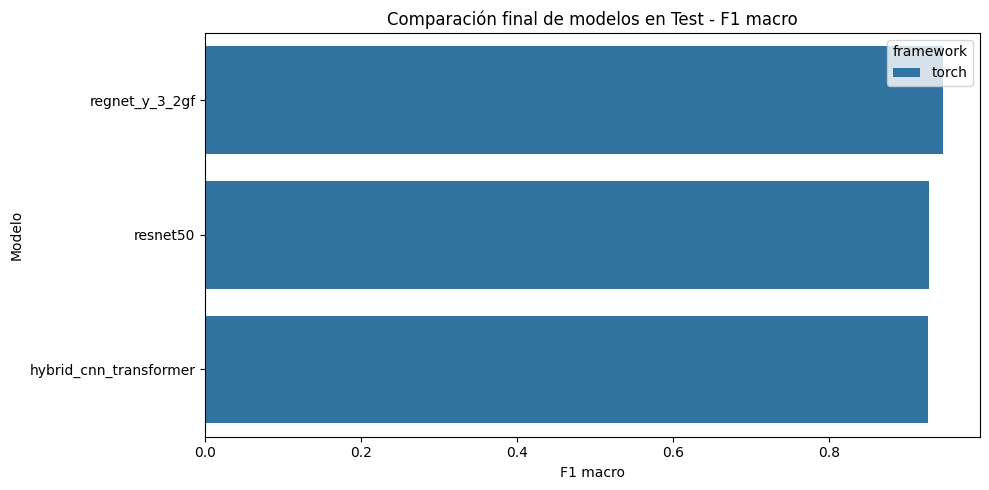

Mejor modelo final:


,framework,model_id,best_ckpt,export_torchscript,export_onnx,final_minutes,top1,top5,macro_precision,macro_recall,macro_f1
0,torch,regnet_y_3_2gf,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,/content/SugarcaneLeafImageDataset19k/experime...,2.1,0.950454,0.998604,0.945572,0.946255,0.945835


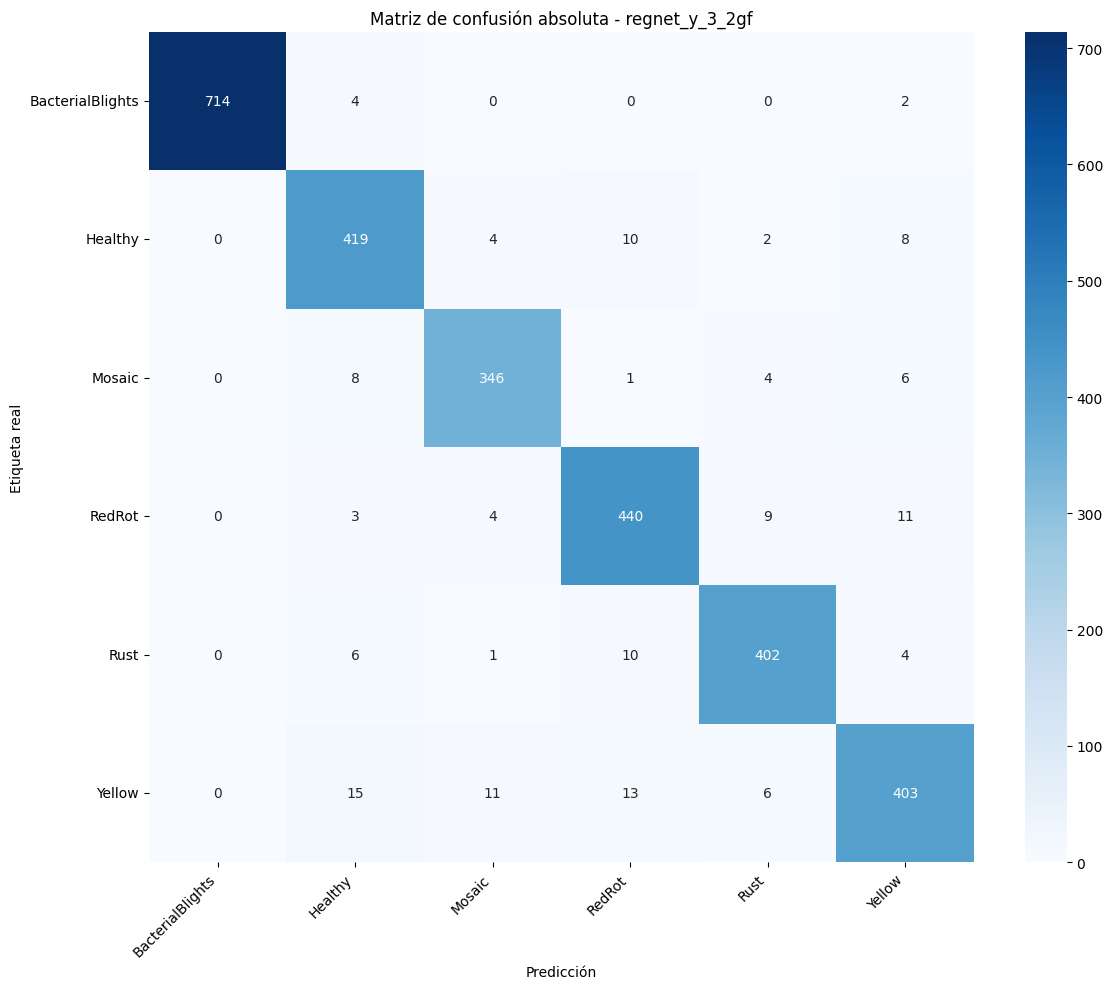

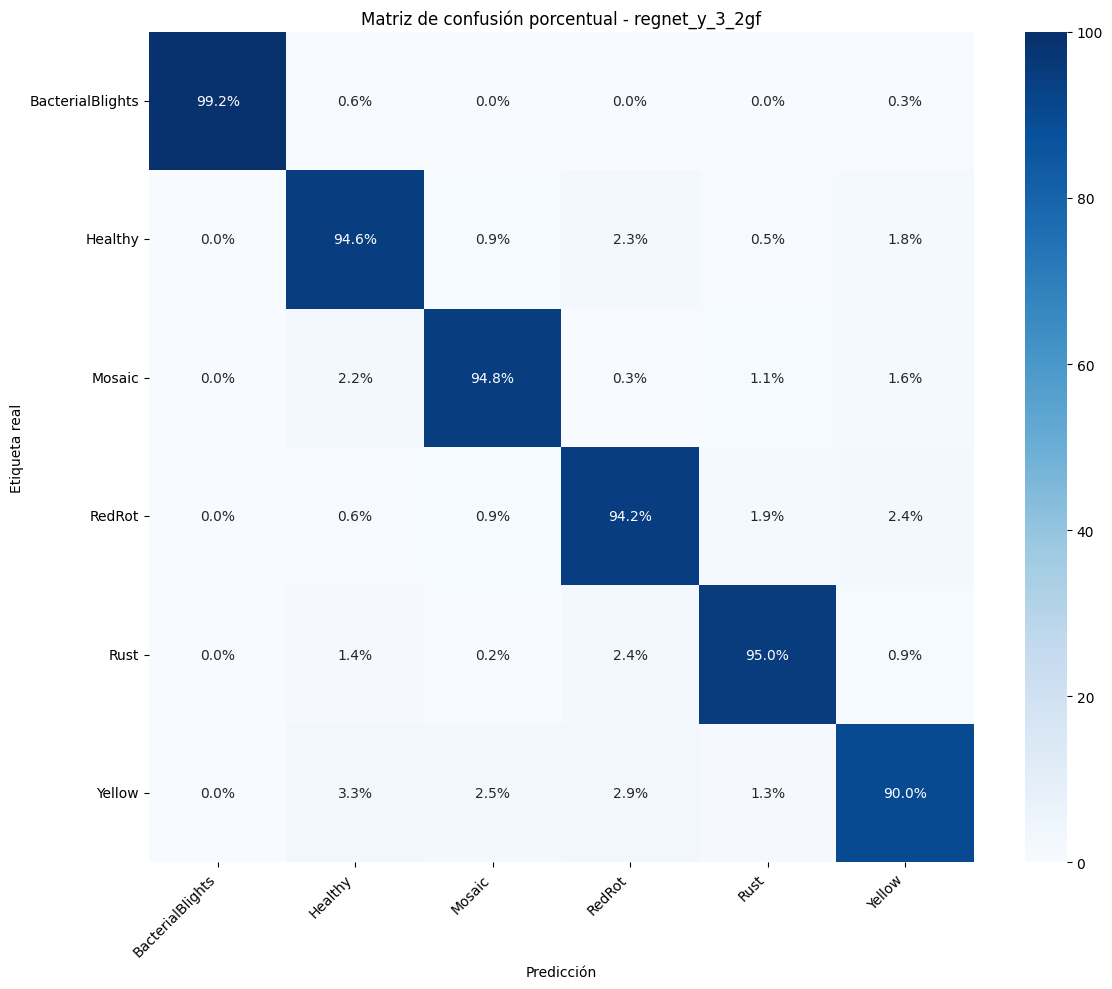

In [20]:
# ============================================================
# CELDA 20. REPORTE FINAL Y MATRIZ DE CONFUSIÓN
# ============================================================

df_final = pd.read_csv(EXP_ROOT / "leaderboard_final_test.csv").sort_values(["macro_f1", "top1"], ascending=False).reset_index(drop=True)
display(df_final)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_final, x="macro_f1", y="model_id", hue="framework", dodge=False)
plt.title("Comparación final de modelos en Test - F1 macro")
plt.xlabel("F1 macro")
plt.ylabel("Modelo")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "final_model_comparison_macro_f1.png", dpi=300)
plt.show()

best_row = df_final.iloc[0]
print("Mejor modelo final:")
display(best_row.to_frame().T)

best_ckpt_path = Path(best_row["best_ckpt"])
candidate_dirs = [best_ckpt_path.parent, best_ckpt_path.parent.parent]

y_true = y_pred = None
for d in candidate_dirs:
    if (d / "test_y_true.npy").exists() and (d / "test_y_pred.npy").exists():
        y_true = np.load(d / "test_y_true.npy")
        y_pred = np.load(d / "test_y_pred.npy")
        break

if y_true is None:
    raise RuntimeError("No se encontraron predicciones guardadas del mejor modelo.")

cm_counts = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_counts,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title(f"Matriz de confusión absoluta - {best_row['model_id']}")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrix_best_model_counts.png", dpi=300)
plt.show()

row_sums = cm_counts.sum(axis=1, keepdims=True)
cm_pct = np.divide(
    cm_counts.astype(np.float64),
    row_sums,
    out=np.zeros_like(cm_counts, dtype=np.float64),
    where=row_sums != 0
) * 100

annot_labels = np.array([[f"{v:.1f}%" for v in row] for row in cm_pct])

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_pct,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=100
)
plt.title(f"Matriz de confusión porcentual - {best_row['model_id']}")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrix_best_model_percentage.png", dpi=300)
plt.show()

pd.DataFrame(cm_counts, index=class_names, columns=class_names).to_csv(REPORTS_DIR / "confusion_matrix_counts.csv")
pd.DataFrame(cm_pct, index=class_names, columns=class_names).to_csv(REPORTS_DIR / "confusion_matrix_percentage.csv")

## Celda 21 — Análisis de errores por clase

Identifica las clases más confundidas y muestra ejemplos visuales de errores. Este análisis es clave para discutir limitaciones del modelo.

Errores totales: 142


,true_class,pred_class,n_errors
18,Yellow,Healthy,15
20,Yellow,RedRot,13
19,Yellow,Mosaic,11
13,RedRot,Yellow,11
3,Healthy,RedRot,10
16,Rust,RedRot,10
12,RedRot,Rust,9
5,Healthy,Yellow,8
6,Mosaic,Healthy,8
9,Mosaic,Yellow,6


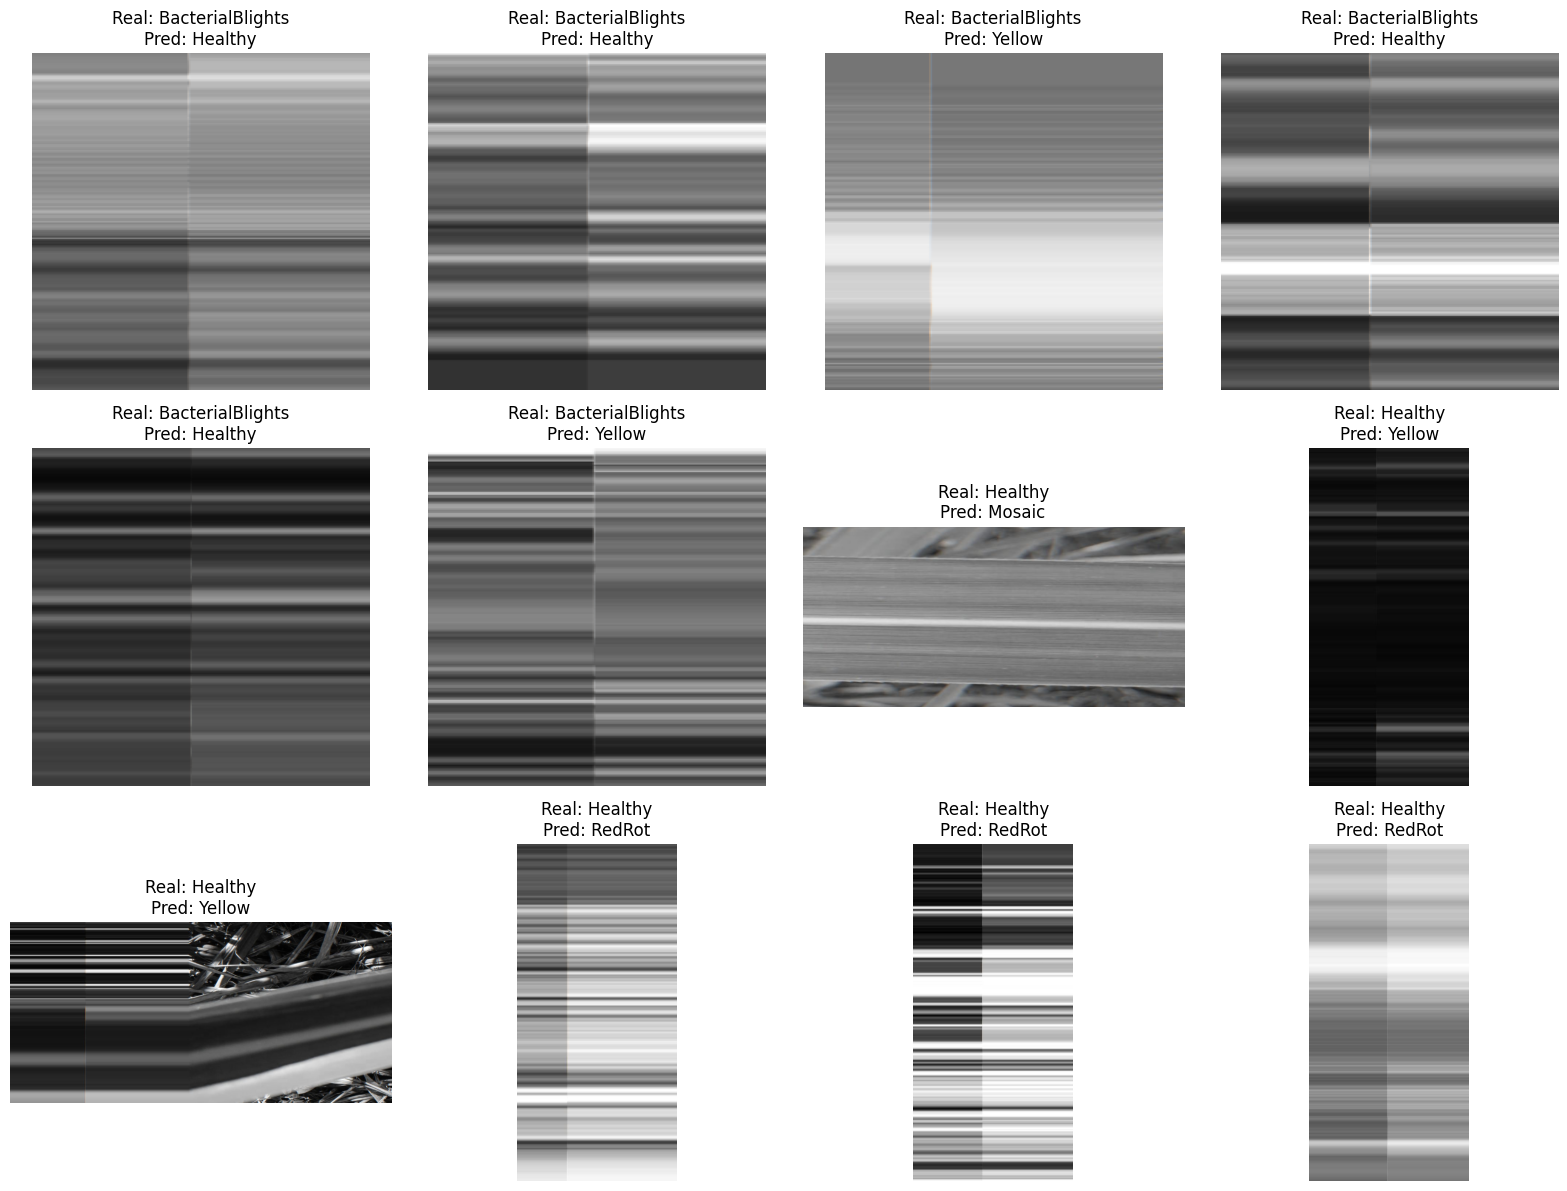

In [21]:
# ============================================================
# CELDA 21. ANÁLISIS DE ERRORES POR CLASE
# ============================================================

# El orden de test_image_paths corresponde a test_y para YOLO y al recorrido por clase.
# Para modelos PyTorch, test_ds.samples contiene las rutas y etiquetas.
if best_row["framework"] == "torch":
    paths_for_errors = [p for p, _ in test_ds.samples]
else:
    paths_for_errors = test_image_paths

errors = []
for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
    if yt != yp:
        errors.append({
            "path": paths_for_errors[i],
            "true_idx": int(yt),
            "pred_idx": int(yp),
            "true_class": class_names[int(yt)],
            "pred_class": class_names[int(yp)]
        })

df_errors = pd.DataFrame(errors)
print("Errores totales:", len(df_errors))

if not df_errors.empty:
    error_summary = (
        df_errors.groupby(["true_class", "pred_class"])
        .size()
        .reset_index(name="n_errors")
        .sort_values("n_errors", ascending=False)
    )
    display(error_summary.head(15))
    error_summary.to_csv(REPORTS_DIR / "error_summary_by_class.csv", index=False)

    sample_errors = df_errors.head(min(12, len(df_errors)))
    cols = 4
    rows = int(np.ceil(len(sample_errors) / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
    for j, (_, row) in enumerate(sample_errors.iterrows(), 1):
        img = Image.open(row["path"]).convert("RGB")
        plt.subplot(rows, cols, j)
        plt.imshow(img)
        plt.title(f"Real: {row['true_class']}\nPred: {row['pred_class']}")
        plt.axis("off")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "sample_prediction_errors.png", dpi=300)
    plt.show()
else:
    print("No se encontraron errores en el conjunto de prueba.")

## Celda 22 — Costo computacional comparativo

Calcula parámetros, tamaño en disco y tiempo/FPS aproximado de inferencia. Esta información permite discutir precisión versus eficiencia.

In [22]:
# ============================================================
# CELDA 22. COSTO COMPUTACIONAL COMPARATIVO
# ============================================================

cost_rows = []
N_WARMUP = 5
N_BENCH = 30

def file_size_mb(path):
    path = Path(path)
    return path.stat().st_size / (1024 * 1024) if path.exists() else np.nan

for _, row in df_final.iterrows():
    fw = row["framework"]
    mid = row["model_id"]
    ckpt_path = Path(row["best_ckpt"])

    if fw == "torch":
        model = build_torch_model(mid, num_classes).to(DEVICE)
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["state_dict"], strict=False)
        model.eval()
        n_params = count_params(model)
        dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

        with torch.no_grad():
            for _ in range(N_WARMUP):
                _ = model(dummy)
            if DEVICE == "cuda":
                torch.cuda.synchronize()
            t0 = time.time()
            for _ in range(N_BENCH):
                _ = model(dummy)
            if DEVICE == "cuda":
                torch.cuda.synchronize()
            elapsed = time.time() - t0

        fps = N_BENCH / elapsed if elapsed > 0 else np.nan
        size_mb = file_size_mb(ckpt_path)
        del model

    else:
        model = YOLO(str(ckpt_path))
        n_params = int(sum(p.numel() for p in model.model.parameters()))
        sample_imgs = test_image_paths[:min(30, len(test_image_paths))]
        for _ in range(2):
            _ = model.predict(sample_imgs[:1], imgsz=IMG_SIZE, verbose=False, device=0 if DEVICE == "cuda" else "cpu")
        t0 = time.time()
        _ = model.predict(sample_imgs, imgsz=IMG_SIZE, verbose=False, device=0 if DEVICE == "cuda" else "cpu")
        elapsed = time.time() - t0
        fps = len(sample_imgs) / elapsed if elapsed > 0 else np.nan
        size_mb = file_size_mb(ckpt_path)
        del model

    cost_rows.append({
        "framework": fw,
        "model_id": mid,
        "params_M": round(n_params / 1e6, 3),
        "model_size_MB": round(size_mb, 3),
        "fps_inference": round(fps, 3)
    })

    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

df_cost = pd.DataFrame(cost_rows).sort_values("fps_inference", ascending=False)
df_cost.to_csv(REPORTS_DIR / "computational_cost_comparison.csv", index=False)
display(df_cost)

,framework,model_id,params_M,model_size_MB,fps_inference
1,torch,resnet50,23.520,90.009,142.521
0,torch,regnet_y_3_2gf,17.932,68.818,67.726
2,torch,hybrid_cnn_transformer,4.941,18.996,62.691


## Celda 23 — Intervalos de confianza con Bootstrap

Calcula intervalos de confianza del 95% para Accuracy y F1 macro sobre las predicciones del conjunto de prueba. Esto cuantifica la incertidumbre estadística.

In [23]:
# ============================================================
# CELDA 23. INTERVALOS DE CONFIANZA BOOTSTRAP
# ============================================================

N_BOOTSTRAP = 1000
CI_ALPHA = 0.05
rng = np.random.default_rng(SEED)

bootstrap_rows = []

for _, row in df_final.iterrows():
    ckpt_path = Path(row["best_ckpt"])
    candidate_dirs = [ckpt_path.parent, ckpt_path.parent.parent]
    yt = yp = None
    for d in candidate_dirs:
        if (d / "test_y_true.npy").exists() and (d / "test_y_pred.npy").exists():
            yt = np.load(d / "test_y_true.npy")
            yp = np.load(d / "test_y_pred.npy")
            break
    if yt is None:
        continue

    n = len(yt)
    acc_values = []
    f1_values = []

    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, n, n)
        acc_values.append(accuracy_score(yt[idx], yp[idx]))
        _, _, f1, _ = precision_recall_fscore_support(yt[idx], yp[idx], average="macro", zero_division=0)
        f1_values.append(f1)

    bootstrap_rows.append({
        "framework": row["framework"],
        "model_id": row["model_id"],
        "accuracy_mean": float(np.mean(acc_values)),
        "accuracy_ci_low": float(np.quantile(acc_values, CI_ALPHA / 2)),
        "accuracy_ci_high": float(np.quantile(acc_values, 1 - CI_ALPHA / 2)),
        "macro_f1_mean": float(np.mean(f1_values)),
        "macro_f1_ci_low": float(np.quantile(f1_values, CI_ALPHA / 2)),
        "macro_f1_ci_high": float(np.quantile(f1_values, 1 - CI_ALPHA / 2)),
    })

df_bootstrap = pd.DataFrame(bootstrap_rows)
df_bootstrap.to_csv(REPORTS_DIR / "bootstrap_confidence_intervals.csv", index=False)
display(df_bootstrap)

,framework,model_id,accuracy_mean,accuracy_ci_low,accuracy_ci_high,macro_f1_mean,macro_f1_ci_low,macro_f1_ci_high
0,torch,regnet_y_3_2gf,0.950378,0.941731,0.958139,0.945703,0.936491,0.954502
1,torch,resnet50,0.934529,0.925680,0.943475,0.928374,0.918803,0.938292
2,torch,hybrid_cnn_transformer,0.933318,0.924285,0.942777,0.926052,0.916442,0.936152


## Celda 24 — K-Fold Cross-Validation sobre modelos finalistas

Validación estadística adicional. Por costo computacional, se recomienda usarla solo sobre el mejor modelo o Top-3, no sobre todas las arquitecturas.

In [ ]:
# ============================================================
# CELDA 24. K-FOLD CROSS-VALIDATION REAL SOBRE TOP-K PYTORCH
# ============================================================
# Validación cruzada estratificada para modelos PyTorch finalistas.
# Se usa train + val. El conjunto test permanece reservado para evaluación final.
#
# Esta celda puede tardar porque ejecuta:
# número_modelos_pytorch_top_k × K_FOLDS × KFOLD_EPOCHS

RUN_KFOLD = True
K_FOLDS = 5
KFOLD_EPOCHS = 10
KFOLD_BATCH_SIZE = BATCH_SIZE

class ImagePathDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = [(str(path), int(label)) for path, label in samples]
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


@torch.no_grad()
def evaluate_torch_loader(model, loader):
    return predict_torch(model, loader)


if RUN_KFOLD:

    if "top_models" not in globals():
        top_models = pd.read_csv(EXP_ROOT / "top_models_for_final.csv")

    torch_top = top_models[top_models["framework"] == "torch"].copy()

    if torch_top.empty:
        print("No hay modelos PyTorch en Top-K para K-Fold. La celda se omite.")
    else:
        base_samples = train_ds.samples + val_ds.samples
        base_targets = np.array([label for _, label in base_samples])

        skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
        kfold_rows = []

        for _, model_row in torch_top.iterrows():
            model_key = model_row["model_id"]
            print(f"\n========== K-FOLD PARA {model_key} ==========")

            for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(base_targets)), base_targets), start=1):
                print(f"\nFold {fold}/{K_FOLDS}")

                train_samples_fold = [base_samples[i] for i in train_idx]
                val_samples_fold = [base_samples[i] for i in val_idx]

                train_fold_ds = ImagePathDataset(train_samples_fold, transform=train_tf)
                val_fold_ds = ImagePathDataset(val_samples_fold, transform=eval_tf)

                train_loader_fold = DataLoader(
                    train_fold_ds,
                    batch_size=KFOLD_BATCH_SIZE,
                    shuffle=True,
                    num_workers=NUM_WORKERS,
                    pin_memory=(DEVICE == "cuda")
                )

                val_loader_fold = DataLoader(
                    val_fold_ds,
                    batch_size=KFOLD_BATCH_SIZE,
                    shuffle=False,
                    num_workers=NUM_WORKERS,
                    pin_memory=(DEVICE == "cuda")
                )

                model = build_torch_model(model_key, num_classes).to(DEVICE)

                fold_targets_train = np.array([label for _, label in train_samples_fold])
                counts_fold = np.bincount(fold_targets_train, minlength=num_classes)
                weights_fold = counts_fold.sum() / np.maximum(counts_fold, 1)
                weights_fold = weights_fold / weights_fold.mean()

                criterion = nn.CrossEntropyLoss(
                    weight=torch.tensor(weights_fold, dtype=torch.float32).to(DEVICE),
                    label_smoothing=0.05
                )

                optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
                scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(KFOLD_EPOCHS, 1))
                scaler = GradScaler("cuda", enabled=(DEVICE == "cuda"))

                start_time = time.time()
                best_val_loss = float("inf")
                best_state = None

                for epoch in range(1, KFOLD_EPOCHS + 1):
                    model.train()
                    train_loss = 0.0
                    train_total = 0

                    for x, y in train_loader_fold:
                        x = x.to(DEVICE, non_blocking=True)
                        y = y.to(DEVICE, non_blocking=True)

                        optimizer.zero_grad(set_to_none=True)

                        with autocast("cuda", enabled=(DEVICE == "cuda")):
                            logits = model(x)
                            loss = criterion(logits, y)

                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                        train_loss += loss.item() * x.size(0)
                        train_total += x.size(0)

                    scheduler.step()

                    model.eval()
                    val_loss = 0.0
                    val_total = 0

                    with torch.no_grad():
                        for x, y in val_loader_fold:
                            x = x.to(DEVICE, non_blocking=True)
                            y = y.to(DEVICE, non_blocking=True)

                            with autocast("cuda", enabled=(DEVICE == "cuda")):
                                logits = model(x)
                                loss = criterion(logits, y)

                            val_loss += loss.item() * x.size(0)
                            val_total += x.size(0)

                    train_loss /= max(train_total, 1)
                    val_loss /= max(val_total, 1)

                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

                    print(
                        f"{model_key} | Fold {fold} | "
                        f"Epoch {epoch}/{KFOLD_EPOCHS} | "
                        f"train_loss={train_loss:.4f} | "
                        f"val_loss={val_loss:.4f}"
                    )

                if best_state is not None:
                    model.load_state_dict(best_state)

                y_true_fold, probs_fold = evaluate_torch_loader(model, val_loader_fold)
                metrics_fold, y_pred_fold = metrics_from_probs(y_true_fold, probs_fold)

                kfold_rows.append({
                    "model_id": model_key,
                    "fold": fold,
                    "epochs": KFOLD_EPOCHS,
                    "best_val_loss": float(best_val_loss),
                    "minutes": round((time.time() - start_time) / 60, 2),
                    **metrics_fold
                })

                del model, train_loader_fold, val_loader_fold, train_fold_ds, val_fold_ds
                gc.collect()
                if DEVICE == "cuda":
                    torch.cuda.empty_cache()

        df_kfold = pd.DataFrame(kfold_rows)
        df_kfold.to_csv(REPORTS_DIR / "kfold_results_full.csv", index=False)
        display(df_kfold)

        df_kfold_summary = (
            df_kfold
            .groupby("model_id")
            .agg({
                "top1": ["mean", "std"],
                "macro_precision": ["mean", "std"],
                "macro_recall": ["mean", "std"],
                "macro_f1": ["mean", "std"],
                "minutes": ["mean", "sum"]
            })
        )

        df_kfold_summary.to_csv(REPORTS_DIR / "kfold_summary_mean_std.csv")
        display(df_kfold_summary)

else:
    print("K-Fold desactivado.")


========== K-FOLD PARA regnet_y_3_2gf ==========

Fold 1/5
regnet_y_3_2gf | Fold 1 | Epoch 1/1 | train_loss=0.6439 | val_loss=0.4247

Fold 2/5
regnet_y_3_2gf | Fold 2 | Epoch 1/1 | train_loss=0.6300 | val_loss=0.4158

Fold 3/5
regnet_y_3_2gf | Fold 3 | Epoch 1/1 | train_loss=0.6436 | val_loss=0.4141

Fold 4/5
regnet_y_3_2gf | Fold 4 | Epoch 1/1 | train_loss=0.6475 | val_loss=0.4192

Fold 5/5
regnet_y_3_2gf | Fold 5 | Epoch 1/1 | train_loss=0.6370 | val_loss=0.4191

========== K-FOLD PARA hybrid_cnn_transformer ==========

Fold 1/5
hybrid_cnn_transformer | Fold 1 | Epoch 1/1 | train_loss=0.8892 | val_loss=0.4672

Fold 2/5
hybrid_cnn_transformer | Fold 2 | Epoch 1/1 | train_loss=0.8886 | val_loss=0.4784

Fold 3/5
hybrid_cnn_transformer | Fold 3 | Epoch 1/1 | train_loss=0.8878 | val_loss=0.4410

Fold 4/5
hybrid_cnn_transformer | Fold 4 | Epoch 1/1 | train_loss=0.8792 | val_loss=0.4465

Fold 5/5
hybrid_cnn_transformer | Fold 5 | Epoch 1/1 | train_loss=0.8744 | val_loss=0.4595

========== 

,model_id,fold,epochs,best_val_loss,minutes,top1,top5,macro_precision,macro_recall,macro_f1
0,regnet_y_3_2gf,1,1,0.424742,2.91,0.937731,0.996917,0.935005,0.933234,0.932306
1,regnet_y_3_2gf,2,1,0.415774,1.48,0.939273,0.997226,0.932274,0.935511,0.933323
2,regnet_y_3_2gf,3,1,0.414087,1.49,0.938039,0.999383,0.934226,0.930445,0.931745
3,regnet_y_3_2gf,4,1,0.419180,1.50,0.936806,0.999692,0.930260,0.931178,0.929533
4,regnet_y_3_2gf,5,1,0.419105,1.48,0.937115,0.996917,0.931082,0.930819,0.929964
5,hybrid_cnn_transformer,1,1,0.467168,2.71,0.917694,0.999075,0.909454,0.909442,0.908561
6,hybrid_cnn_transformer,2,1,0.478431,1.49,0.911529,0.996917,0.903255,0.902770,0.901878
7,hybrid_cnn_transformer,3,1,0.441017,1.51,0.922935,0.995376,0.917828,0.914830,0.916024
8,hybrid_cnn_transformer,4,1,0.446539,1.51,0.925709,0.996917,0.923754,0.917228,0.918346
9,hybrid_cnn_transformer,5,1,0.459481,1.50,0.917694,0.997842,0.909422,0.910153,0.909315


top1           macro_precision            \
                            mean       std            mean       std   
model_id                                                               
hybrid_cnn_transformer  0.919112  0.005469        0.912743  0.008046   
regnet_y_3_2gf          0.937793  0.000960        0.932569  0.002019   
resnet50                0.926757  0.003237        0.922117  0.004063   

                       macro_recall            macro_f1           minutes  \
                               mean       std      mean       std    mean   
model_id                                                                    
hybrid_cnn_transformer     0.910885  0.005574  0.910825  0.006539   1.744   
regnet_y_3_2gf             0.932237  0.002125  0.931374  0.001596   1.772   
resnet50                   0.920220  0.003484  0.919875  0.003685   1.660   

                              
                         sum  
model_id                      
hybrid_cnn_transformer  8.72  
regnet_y_3_2gf          8.86  
resnet50                8.30

## Celda 25 — Explicabilidad con Grad-CAM para el mejor modelo PyTorch

Genera mapas de calor para modelos CNN/Transformer compatibles con PyTorch. Si el mejor modelo final es YOLO o no hay modelo PyTorch, la celda se omite.

Modelo PyTorch usado para Grad-CAM: regnet_y_3_2gf
Checkpoint: /content/SugarcaneLeafImageDataset19k/experiments/final/torch/regnet_y_3_2gf/best.pt
Capa objetivo Grad-CAM: trunk_output.block4.block4-0.f.c.0 Conv2d(1512, 1512, kernel_size=(1, 1), stride=(1, 1), bias=False)


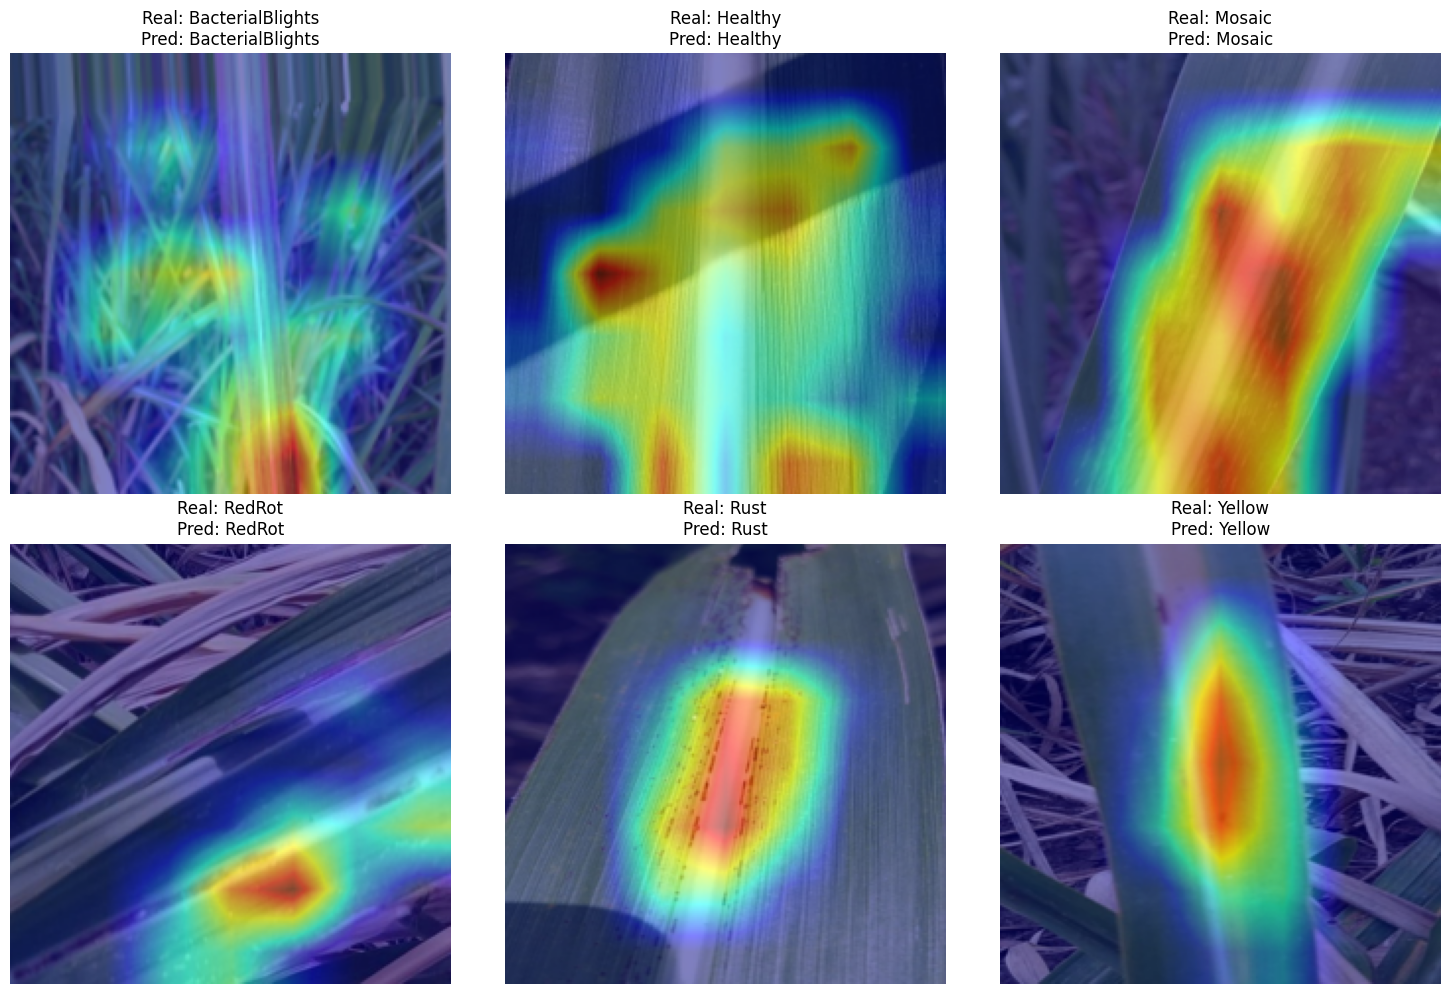

In [25]:
# ============================================================
# CELDA 25. EXPLICABILIDAD CON GRAD-CAM
# ============================================================
# Grad-CAM se aplica sobre el mejor modelo PyTorch finalista.
# Si el ganador global es YOLO, se selecciona el mejor PyTorch disponible
# para generar evidencia de explicabilidad visual.

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    gradcam_available = True
except Exception as e:
    print("Grad-CAM no disponible:", e)
    print("Instala con: !pip install -q grad-cam")
    gradcam_available = False


def find_target_layer_for_gradcam(model):
    last_conv_name = None
    last_conv_module = None

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv_name = name
            last_conv_module = module

    return last_conv_name, last_conv_module


if gradcam_available:
    if "df_final" not in globals():
        df_final = pd.read_csv(EXP_ROOT / "leaderboard_final_test.csv")

    torch_final = (
        df_final[df_final["framework"] == "torch"]
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )

    if torch_final.empty:
        print("No hay modelos PyTorch finales para Grad-CAM. Si el mejor modelo es YOLO, esta celda se omite.")
    else:
        row = torch_final.iloc[0]
        model_key = row["model_id"]
        ckpt_path = Path(row["best_ckpt"])

        print("Modelo PyTorch usado para Grad-CAM:", model_key)
        print("Checkpoint:", ckpt_path)

        model = build_torch_model(model_key, num_classes).to(DEVICE)
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["state_dict"], strict=False)
        model.eval()

        target_layer_name, target_layer = find_target_layer_for_gradcam(model)

        if target_layer is None:
            print("No se identificó una capa Conv2d para Grad-CAM. Este modelo puede ser un Transformer puro.")
        else:
            print("Capa objetivo Grad-CAM:", target_layer_name, target_layer)

            selected_samples = []
            seen_classes = set()

            for path, label in test_ds.samples:
                if label not in seen_classes:
                    selected_samples.append((path, label))
                    seen_classes.add(label)
                if len(selected_samples) >= min(num_classes, 6):
                    break

            gradcam_dir = REPORTS_DIR / "gradcam"
            gradcam_dir.mkdir(parents=True, exist_ok=True)

            cam = GradCAM(model=model, target_layers=[target_layer])

            cols = 3
            rows = int(np.ceil(len(selected_samples) / cols))
            plt.figure(figsize=(cols * 5, rows * 5))

            for i, (sample_path, true_label) in enumerate(selected_samples, 1):
                img = Image.open(sample_path).convert("RGB")
                img_resized = img.resize((IMG_SIZE, IMG_SIZE))
                rgb_img = np.asarray(img_resized).astype(np.float32) / 255.0

                input_tensor = eval_tf(img).unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    logits = model(input_tensor)
                    pred_idx = int(logits.argmax(1).item())

                grayscale_cam = cam(
                    input_tensor=input_tensor,
                    targets=[ClassifierOutputTarget(pred_idx)]
                )[0]

                visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

                out_path = gradcam_dir / f"gradcam_{i}_{class_names[true_label]}_pred_{class_names[pred_idx]}.png"
                Image.fromarray(visualization).save(out_path)

                plt.subplot(rows, cols, i)
                plt.imshow(visualization)
                plt.title(f"Real: {class_names[true_label]}\nPred: {class_names[pred_idx]}")
                plt.axis("off")

            plt.tight_layout()
            plt.savefig(REPORTS_DIR / "gradcam_best_torch_model_grid.png", dpi=300)
            plt.show()

        del model
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

## Celda 26 — Resumen ejecutivo y compresión del experimento

Guarda un resumen JSON y comprime resultados, reportes, métricas y artefactos para entrega.

In [26]:
# ============================================================
# CELDA 26. RESUMEN FINAL Y COMPRESIÓN
# ============================================================

df_final_path = EXP_ROOT / "leaderboard_final_test.csv"
df_final_loaded = pd.read_csv(df_final_path) if df_final_path.exists() else pd.DataFrame()

final_summary = {
    "project": "Clasificación automática de enfermedades foliares en caña de azúcar",
    "methodological_flow": [
        "EDA",
        "Limpieza de imágenes corruptas y duplicados MD5",
        "Split train/validation/test",
        "Data augmentation solo en train",
        "Screening PyTorch en validation",
        "Screening YOLO en validation",
        "Selección Top-K",
        "Fine-tuning de finalistas",
        "Evaluación final única en test",
        "Matriz de confusión porcentual",
        "Análisis de errores",
        "Costo computacional",
        "Bootstrap IC95%",
        "K-Fold PyTorch finalistas",
        "Grad-CAM",
        "Exportación y best.pt"
    ],
    "seed": SEED,
    "device": DEVICE,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "raw_dir": str(RAW_DIR),
    "clean_dir": str(CLEAN_DIR),
    "data_dir": str(DATA_DIR),
    "experiment_root": str(EXP_ROOT),
    "reports_dir": str(REPORTS_DIR),
    "best_model_dir": str(BEST_MODEL_DIR),
    "num_classes": int(num_classes) if "num_classes" in globals() else None,
    "class_names": class_names if "class_names" in globals() else None,
    "screening_evaluation_split": "validation",
    "final_evaluation_split": "test",
    "canonical_best_pt": str(BEST_MODEL_DIR / "best.pt"),
    "best_model": df_final_loaded.sort_values(["macro_f1", "top1"], ascending=False).iloc[0].to_dict() if not df_final_loaded.empty else None
}

save_json(final_summary, REPORTS_DIR / "final_experiment_summary.json")

archive_base = PROJECT_ROOT / "proyecto3_experimento_completo"
shutil.make_archive(str(archive_base), "zip", root_dir=PROJECT_ROOT)

print("Resumen guardado en:", REPORTS_DIR / "final_experiment_summary.json")
print("best.pt canónico esperado en:", BEST_MODEL_DIR / "best.pt")
print("Archivo comprimido:", str(archive_base) + ".zip")

Resumen guardado en: /content/SugarcaneLeafImageDataset19k/reports/final_experiment_summary.json
best.pt canónico esperado en: /content/SugarcaneLeafImageDataset19k/best_model/best.pt
Archivo comprimido: /content/SugarcaneLeafImageDataset19k/proyecto3_experimento_completo.zip


## Texto metodológico breve para el informe

El flujo experimental se estructuró en tres fases principales. Primero, se realizó la preparación del conjunto de datos mediante análisis exploratorio, verificación de imágenes corruptas, detección de duplicados exactos mediante hashes MD5 y organización en subconjuntos de entrenamiento, validación y prueba. Segundo, se ejecutó un screening experimental de arquitecturas de clasificación, incluyendo modelos PyTorch y YOLO Classification, usando el conjunto de validación para seleccionar los modelos finalistas sin comprometer el conjunto de prueba. Tercero, los modelos seleccionados fueron sometidos a fine-tuning y evaluados finalmente sobre el conjunto de prueba. Adicionalmente, se incorporaron análisis de matriz de confusión porcentual, errores por clase, costo computacional, intervalos de confianza por bootstrap, validación cruzada estratificada y Grad-CAM como mecanismos de trazabilidad, robustez estadística e interpretabilidad.